In [1]:
# ============================================================
# CELL 1: IMPORTS & ENVIRONMENT VERIFICATION
# ============================================================

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import warnings
import json
from collections import Counter
import gc

warnings.filterwarnings('ignore')

# ── Verify Kaggle paths ──────────────────────────────────────
INPUT_BASE = Path("/kaggle/input/datasets/jessicali9530/celeba-dataset")

# Check all expected files exist
EXPECTED_FILES = [
    "list_attr_celeba.csv",
    "list_eval_partition.csv",
    "img_align_celeba/img_align_celeba",  # nested folder on Kaggle
]

print("=" * 60)
print("ENVIRONMENT VERIFICATION")
print("=" * 60)

for f in EXPECTED_FILES:
    full_path = INPUT_BASE / f
    exists = full_path.exists()
    print(f"  {'✓' if exists else '✗'} {f}")

# ── Output path ──────────────────────────────────────────────
OUTPUT_DIR = Path("/kaggle/working")
MANIFEST_PATH = OUTPUT_DIR / "manifest.csv"
STATS_PATH    = OUTPUT_DIR / "dataset_stats.json"
print(f"\n  Output Directory : {OUTPUT_DIR}")
print(f"  Manifest will be : {MANIFEST_PATH}")

# ── Image directory (Kaggle nests this folder) ───────────────
IMG_DIR = INPUT_BASE / "img_align_celeba" / "img_align_celeba"
if not IMG_DIR.exists():
    # fallback if single level
    IMG_DIR = INPUT_BASE / "img_align_celeba"
print(f"  Image Directory  : {IMG_DIR}")
print(f"  Images found     : {len(list(IMG_DIR.glob('*.jpg'))):,}")
print("=" * 60)

ENVIRONMENT VERIFICATION
  ✓ list_attr_celeba.csv
  ✓ list_eval_partition.csv
  ✓ img_align_celeba/img_align_celeba

  Output Directory : /kaggle/working
  Manifest will be : /kaggle/working/manifest.csv
  Image Directory  : /kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba
  Images found     : 202,599


In [2]:
# ============================================================
# CELL 2: LOAD RAW CELEBA ATTRIBUTE & PARTITION FILES
# ============================================================

print("Loading CelebA attribute file...")
attr_path      = INPUT_BASE / "list_attr_celeba.csv"
partition_path = INPUT_BASE / "list_eval_partition.csv"

df_attr = pd.read_csv(attr_path)
df_part = pd.read_csv(partition_path)

# ── Standardize column names ─────────────────────────────────
# Kaggle version uses 'image_id' as first column
print(f"\nAttribute CSV shape    : {df_attr.shape}")
print(f"Partition CSV shape    : {df_part.shape}")
print(f"\nAttribute columns (first 6): {df_attr.columns[:6].tolist()}")
print(f"Partition columns          : {df_part.columns.tolist()}")

# ── Rename for consistency ───────────────────────────────────
# Some Kaggle versions have slight naming variations
df_attr.rename(columns={"image_id": "image_id"}, inplace=True)
df_part.rename(columns={"image_id": "image_id",
                         "partition": "partition"}, inplace=True)

# ── Verify target columns exist ──────────────────────────────
TARGET_ATTRS = ["Bags_Under_Eyes", "Chubby", "Double_Chin"]
GENDER_COL   = "Male"

print("\nVerifying target columns:")
for col in TARGET_ATTRS + [GENDER_COL]:
    assert col in df_attr.columns, f"MISSING COLUMN: {col}"
    vc = df_attr[col].value_counts().to_dict()
    print(f"  {col:<20s} → {vc}")

print(f"\nTotal images in attribute file : {len(df_attr):,}")
print(f"Total images in partition file : {len(df_part):,}")

Loading CelebA attribute file...

Attribute CSV shape    : (202599, 41)
Partition CSV shape    : (202599, 2)

Attribute columns (first 6): ['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald']
Partition columns          : ['image_id', 'partition']

Verifying target columns:
  Bags_Under_Eyes      → {-1: 161153, 1: 41446}
  Chubby               → {-1: 190936, 1: 11663}
  Double_Chin          → {-1: 193140, 1: 9459}
  Male                 → {-1: 118165, 1: 84434}

Total images in attribute file : 202,599
Total images in partition file : 202,599


In [3]:
# ============================================================
# CELL 3: RAW DISTRIBUTION ANALYSIS (PRE-FILTER)
# ============================================================

print("=" * 60)
print("RAW CELEBA DISTRIBUTION (all 202,599 images)")
print("=" * 60)

stats_raw = {}

for col in TARGET_ATTRS + [GENDER_COL]:
    pos  = (df_attr[col] ==  1).sum()
    neg  = (df_attr[col] == -1).sum()
    total = len(df_attr)
    stats_raw[col] = {"positive": int(pos), "negative": int(neg),
                      "pct_positive": round(pos/total*100, 2)}
    print(f"\n  {col}")
    print(f"    Positive (+1) : {pos:>7,}  ({pos/total*100:.2f}%)")
    print(f"    Negative (-1) : {neg:>7,}  ({neg/total*100:.2f}%)")

# ── Co-occurrence matrix ─────────────────────────────────────
print("\n\nCO-OCCURRENCE (images with multiple positive attrs):")
print("-" * 50)

df_pos = (df_attr[TARGET_ATTRS] == 1).astype(int)

# How many images have 0, 1, 2, 3 positives
df_attr["_n_positive"] = df_pos.sum(axis=1)
cnt = df_attr["_n_positive"].value_counts().sort_index()
for k, v in cnt.items():
    print(f"  {k} attribute(s) positive → {v:>7,} images  "
          f"({v/len(df_attr)*100:.2f}%)")

# Pairwise co-occurrence
print("\nPairwise co-occurrence (both == 1):")
for i, a in enumerate(TARGET_ATTRS):
    for b in TARGET_ATTRS[i+1:]:
        both = ((df_attr[a] == 1) & (df_attr[b] == 1)).sum()
        print(f"  {a} & {b}: {both:,}")

df_attr.drop(columns=["_n_positive"], inplace=True)

RAW CELEBA DISTRIBUTION (all 202,599 images)

  Bags_Under_Eyes
    Positive (+1) :  41,446  (20.46%)
    Negative (-1) : 161,153  (79.54%)

  Chubby
    Positive (+1) :  11,663  (5.76%)
    Negative (-1) : 190,936  (94.24%)

  Double_Chin
    Positive (+1) :   9,459  (4.67%)
    Negative (-1) : 193,140  (95.33%)

  Male
    Positive (+1) :  84,434  (41.68%)
    Negative (-1) : 118,165  (58.32%)


CO-OCCURRENCE (images with multiple positive attrs):
--------------------------------------------------
  0 attribute(s) positive → 153,453 images  (75.74%)
  1 attribute(s) positive →  38,858 images  (19.18%)
  2 attribute(s) positive →   7,154 images  (3.53%)
  3 attribute(s) positive →   3,134 images  (1.55%)

Pairwise co-occurrence (both == 1):
  Bags_Under_Eyes & Chubby: 5,380
  Bags_Under_Eyes & Double_Chin: 5,318
  Chubby & Double_Chin: 5,858


In [4]:
# ============================================================
# CELL 4: TIER 1 — POSITIVE POOL (at least one attr == +1)
# ============================================================

print("=" * 60)
print("TIER 1: POSITIVE POOL EXTRACTION")
print("=" * 60)

# ── Filter: at least one target attribute == 1 ───────────────
mask_tier1 = (
    (df_attr["Bags_Under_Eyes"] == 1) |
    (df_attr["Chubby"]          == 1) |
    (df_attr["Double_Chin"]     == 1)
)

df_tier1 = df_attr[mask_tier1].copy()
df_tier1["source_tier"] = 1

print(f"\n  Total images with ≥1 positive attribute: {len(df_tier1):,}")

# ── Breakdown within Tier 1 ──────────────────────────────────
print("\n  Breakdown within Tier 1:")
for col in TARGET_ATTRS:
    pos = (df_tier1[col] == 1).sum()
    neg = (df_tier1[col] == -1).sum()
    print(f"    {col:<20s} → pos: {pos:>6,}  neg: {neg:>6,}")

# Gender breakdown in Tier 1
male_t1   = (df_tier1["Male"] ==  1).sum()
female_t1 = (df_tier1["Male"] == -1).sum()
print(f"\n  Gender in Tier 1:")
print(f"    Male   : {male_t1:,}  ({male_t1/len(df_tier1)*100:.1f}%)")
print(f"    Female : {female_t1:,}  ({female_t1/len(df_tier1)*100:.1f}%)")

# ── Validate image files exist ───────────────────────────────
print("\n  Validating image file existence (sampling 500)...")
sample_check = df_tier1["image_id"].sample(500, random_state=42)
missing = [img for img in sample_check
           if not (IMG_DIR / img).exists()]
print(f"  Missing images in sample: {len(missing)}")

TIER 1: POSITIVE POOL EXTRACTION

  Total images with ≥1 positive attribute: 49,146

  Breakdown within Tier 1:
    Bags_Under_Eyes      → pos: 41,446  neg:  7,700
    Chubby               → pos: 11,663  neg: 37,483
    Double_Chin          → pos:  9,459  neg: 39,687

  Gender in Tier 1:
    Male   : 35,667  (72.6%)
    Female : 13,479  (27.4%)

  Validating image file existence (sampling 500)...
  Missing images in sample: 0


In [5]:
# ============================================================
# CELL 5: TIER 2 — FEMALE NEGATIVE/UNSURE POOL
# ============================================================

print("=" * 60)
print("TIER 2: FEMALE NEGATIVE/UNSURE POOL")
print("=" * 60)

TARGET_TOTAL = 100_000

# ── Images NOT in Tier 1 ─────────────────────────────────────
tier1_ids     = set(df_tier1["image_id"])
df_remaining  = df_attr[~df_attr["image_id"].isin(tier1_ids)].copy()
print(f"\n  Images remaining after Tier 1 removal: {len(df_remaining):,}")

# ── Female filter ────────────────────────────────────────────
# Male == -1 → Female
mask_female = df_remaining["Male"] == -1
df_female   = df_remaining[mask_female].copy()
print(f"  Female images in remaining pool     : {len(df_female):,}")

# ── All target attrs must be -1 or NOT +1 ────────────────────
# These are all negative since they didn't pass Tier 1 mask
# (none of them have any +1 for our 3 targets)
# Just double-check:
sanity = (
    (df_female["Bags_Under_Eyes"] == 1) |
    (df_female["Chubby"]          == 1) |
    (df_female["Double_Chin"]     == 1)
).sum()
assert sanity == 0, f"SANITY FAIL: {sanity} positives in Tier 2 pool"
print(f"  Sanity check (no positives leaked): PASSED ✓")

# ── How many do we need from Tier 2? ─────────────────────────
NEEDED_FROM_TIER2 = TARGET_TOTAL - len(df_tier1)
AVAILABLE_FEMALE  = len(df_female)
TAKE_FROM_TIER2   = min(NEEDED_FROM_TIER2, AVAILABLE_FEMALE)

print(f"\n  Target total dataset size : {TARGET_TOTAL:,}")
print(f"  Already have (Tier 1)     : {len(df_tier1):,}")
print(f"  Need from Tier 2+         : {NEEDED_FROM_TIER2:,}")
print(f"  Available female images   : {AVAILABLE_FEMALE:,}")
print(f"  Taking from Tier 2        : {TAKE_FROM_TIER2:,}")

# ── Sample Tier 2 ────────────────────────────────────────────
df_tier2 = df_female.sample(
    n=TAKE_FROM_TIER2,
    random_state=42
).copy()
df_tier2["source_tier"] = 2

print(f"\n  Tier 2 sampled            : {len(df_tier2):,}")

# ── Verify attribute distribution in Tier 2 ─────────────────
print("\n  Attribute distribution in Tier 2 (all should be -1):")
for col in TARGET_ATTRS:
    vc = df_tier2[col].value_counts().to_dict()
    print(f"    {col:<20s} → {vc}")

TIER 2: FEMALE NEGATIVE/UNSURE POOL

  Images remaining after Tier 1 removal: 153,453
  Female images in remaining pool     : 104,686
  Sanity check (no positives leaked): PASSED ✓

  Target total dataset size : 100,000
  Already have (Tier 1)     : 49,146
  Need from Tier 2+         : 50,854
  Available female images   : 104,686
  Taking from Tier 2        : 50,854

  Tier 2 sampled            : 50,854

  Attribute distribution in Tier 2 (all should be -1):
    Bags_Under_Eyes      → {-1: 50854}
    Chubby               → {-1: 50854}
    Double_Chin          → {-1: 50854}


In [6]:
# ============================================================
# CELL 6: TIER 3 — MALE NEGATIVE FILL (if space remains)
# ============================================================

print("=" * 60)
print("TIER 3: MALE FILL POOL (if needed)")
print("=" * 60)

current_total = len(df_tier1) + len(df_tier2)
STILL_NEEDED  = TARGET_TOTAL - current_total

print(f"\n  Current total (Tier1 + Tier2) : {current_total:,}")
print(f"  Still needed to reach 100K    : {STILL_NEEDED:,}")

if STILL_NEEDED > 0:
    # ── Images not yet selected ──────────────────────────────
    selected_ids = tier1_ids | set(df_tier2["image_id"])
    df_remaining2 = df_attr[
        ~df_attr["image_id"].isin(selected_ids)
    ].copy()

    # ── Male filter ──────────────────────────────────────────
    mask_male = df_remaining2["Male"] == 1
    df_male   = df_remaining2[mask_male].copy()

    # Sanity: no positives
    sanity2 = (
        (df_male["Bags_Under_Eyes"] == 1) |
        (df_male["Chubby"]          == 1) |
        (df_male["Double_Chin"]     == 1)
    ).sum()
    assert sanity2 == 0, f"SANITY FAIL Tier3: {sanity2}"

    TAKE_FROM_TIER3 = min(STILL_NEEDED, len(df_male))

    df_tier3 = df_male.sample(
        n=TAKE_FROM_TIER3,
        random_state=42
    ).copy()
    df_tier3["source_tier"] = 3

    print(f"  Available male images         : {len(df_male):,}")
    print(f"  Taking from Tier 3            : {len(df_tier3):,}")

else:
    # Create empty df with same columns so concat works
    df_tier3 = pd.DataFrame(columns=df_tier1.columns)
    df_tier3["source_tier"] = pd.Series(dtype=int)
    print("  Tier 3 NOT NEEDED — dataset already at 100K ✓")

print(f"\n  Final count check:")
print(f"    Tier 1 : {len(df_tier1):,}")
print(f"    Tier 2 : {len(df_tier2):,}")
print(f"    Tier 3 : {len(df_tier3):,}")
print(f"    TOTAL  : {len(df_tier1)+len(df_tier2)+len(df_tier3):,}")

TIER 3: MALE FILL POOL (if needed)

  Current total (Tier1 + Tier2) : 100,000
  Still needed to reach 100K    : 0
  Tier 3 NOT NEEDED — dataset already at 100K ✓

  Final count check:
    Tier 1 : 49,146
    Tier 2 : 50,854
    Tier 3 : 0
    TOTAL  : 100,000


In [7]:
# ============================================================
# CELL 7: MERGE ALL TIERS & BUILD UNIFIED MANIFEST
# ============================================================

print("=" * 60)
print("BUILDING UNIFIED MANIFEST")
print("=" * 60)

# ── Concatenate all tiers ────────────────────────────────────
df_all = pd.concat(
    [df_tier1, df_tier2, df_tier3],
    axis=0,
    ignore_index=True
)

print(f"\n  Combined dataset size: {len(df_all):,}")

# ── Assert no duplicates ─────────────────────────────────────
n_dupes = df_all["image_id"].duplicated().sum()
assert n_dupes == 0, f"DUPLICATE IMAGES FOUND: {n_dupes}"
print(f"  Duplicate check: PASSED ✓ (0 duplicates)")

# ── Merge with partition file ────────────────────────────────
df_all = df_all.merge(
    df_part[["image_id", "partition"]],
    on="image_id",
    how="left"
)

# Map partition int to string
partition_map = {0: "train", 1: "val", 2: "test"}
df_all["split"] = df_all["partition"].map(partition_map)
df_all.drop(columns=["partition"], inplace=True)

print(f"\n  Split distribution:")
for split, cnt in df_all["split"].value_counts().sort_index().items():
    print(f"    {split:<6s}: {cnt:>7,}  ({cnt/len(df_all)*100:.1f}%)")

# ── Build img_path column ────────────────────────────────────
# Store relative path (portable across machines)
df_all["img_path"] = df_all["image_id"].apply(
    lambda x: str(IMG_DIR / x)
)

# ── Map gender to readable ───────────────────────────────────
# Keep original Male column (+1/-1) and add readable
df_all["gender"] = df_all["Male"]  # +1=male, -1=female

# ── Remap attribute values to 0/1/-1 scheme ─────────────────
# CelebA raw: +1 = present, -1 = absent
# Our scheme:  1 = positive, -1 = negative, 0 = unsure
# Since CelebA has no "unsure", all values remain +1 or -1
# (Tier 2 & 3 are all -1, Tier 1 has mixed)
# We just confirm and keep as-is
for col in TARGET_ATTRS:
    assert df_all[col].isin([1, -1]).all(), \
        f"Unexpected value in {col}"

print(f"\n  Attribute value mapping: CONFIRMED ✓ (only +1/-1 in CelebA)")

# ── Add placeholder for MediaPipe path (Phase 2) ────────────
df_all["mediapipe_path"] = ""  # will be filled in Phase 2

print(f"\n  Final manifest columns: {df_all.columns.tolist()}")

BUILDING UNIFIED MANIFEST

  Combined dataset size: 100,000
  Duplicate check: PASSED ✓ (0 duplicates)

  Split distribution:
    test  :  10,026  (10.0%)
    train :  80,280  (80.3%)
    val   :   9,694  (9.7%)

  Attribute value mapping: CONFIRMED ✓ (only +1/-1 in CelebA)

  Final manifest columns: ['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young', 'source_tier', 'split', 'img_path', 'gender', 'mediapipe_path']


In [8]:
# ============================================================
# CELL 8: COMPUTE SAMPLE WEIGHTS (for WeightedRandomSampler)
# ============================================================

print("=" * 60)
print("COMPUTING SAMPLE WEIGHTS")
print("=" * 60)

# ── Strategy: weight based on rarest positive attribute ──────
# For images with positives → weight inversely to class freq
# For images with all negatives → base weight of 1.0

# ── Compute per-attribute positive frequencies ───────────────
train_df = df_all[df_all["split"] == "train"].copy()

print("\n  Training set attribute frequencies:")
attr_pos_freq = {}
for col in TARGET_ATTRS:
    n_pos   = (train_df[col] == 1).sum()
    n_total = len(train_df)
    freq    = n_pos / n_total
    attr_pos_freq[col] = freq
    print(f"    {col:<20s}: {n_pos:>6,} / {n_total:,} = {freq:.4f}")

# ── Weight formula ───────────────────────────────────────────
# weight_i = max over attributes of (1/freq_attr) if attr_i == 1
# For all-negative samples → weight = 1.0

def compute_sample_weight(row):
    """
    For each image:
      - Find which target attributes are positive (==1)
      - Take the MAX inverse frequency among positive attrs
      - This ensures rare-attribute images get highest weight
      - All-negative images get weight = 1.0
    """
    weights_for_image = []
    for col in TARGET_ATTRS:
        if row[col] == 1:
            w = 1.0 / (attr_pos_freq[col] + 1e-8)
            weights_for_image.append(w)

    if len(weights_for_image) == 0:
        return 1.0
    else:
        return max(weights_for_image)

print("\n  Computing sample weights (may take ~30 seconds)...")
df_all["sample_weight"] = df_all.apply(
    compute_sample_weight, axis=1
)

# ── Weight statistics ─────────────────────────────────────────
print("\n  Sample weight statistics:")
print(f"    Min    : {df_all['sample_weight'].min():.4f}")
print(f"    Max    : {df_all['sample_weight'].max():.4f}")
print(f"    Mean   : {df_all['sample_weight'].mean():.4f}")
print(f"    Median : {df_all['sample_weight'].median():.4f}")

# Weight by tier
print("\n  Mean weight by tier:")
for tier in [1, 2, 3]:
    sub = df_all[df_all["source_tier"] == tier]
    if len(sub) > 0:
        print(f"    Tier {tier}: {sub['sample_weight'].mean():.4f}  "
              f"(n={len(sub):,})")

# ── Compute positive class weights for BCE loss ───────────────
# These go into the model loss — save separately
pos_weights = {}
for col in TARGET_ATTRS:
    n_pos = (train_df[col] ==  1).sum()
    n_neg = (train_df[col] == -1).sum()
    pos_weights[col] = round(n_neg / (n_pos + 1e-8), 4)
    print(f"\n  BCE pos_weight for {col}: "
          f"{n_neg:,} / {n_pos:,} = {pos_weights[col]:.2f}")

print("\n  → These pos_weights will be used in WeightedBCELoss")

COMPUTING SAMPLE WEIGHTS

  Training set attribute frequencies:
    Bags_Under_Eyes     : 33,280 / 80,280 = 0.4145
    Chubby              :  9,389 / 80,280 = 0.1170
    Double_Chin         :  7,571 / 80,280 = 0.0943

  Computing sample weights (may take ~30 seconds)...

  Sample weight statistics:
    Min    : 1.0000
    Max    : 10.6036
    Mean   : 2.8252
    Median : 1.0000

  Mean weight by tier:
    Tier 1: 4.7139  (n=49,146)
    Tier 2: 1.0000  (n=50,854)

  BCE pos_weight for Bags_Under_Eyes: 47,000 / 33,280 = 1.41

  BCE pos_weight for Chubby: 70,891 / 9,389 = 7.55

  BCE pos_weight for Double_Chin: 72,709 / 7,571 = 9.60

  → These pos_weights will be used in WeightedBCELoss


In [9]:
# ============================================================
# CELL 9: FINAL MANIFEST CLEANUP & SAVE
# ============================================================

print("=" * 60)
print("FINAL MANIFEST PREPARATION & SAVE")
print("=" * 60)

# ── Select & order final columns ─────────────────────────────
FINAL_COLUMNS = [
    "image_id",          # filename e.g. 000001.jpg
    "img_path",          # absolute path on Kaggle
    "source_tier",       # 1 / 2 / 3
    "Bags_Under_Eyes",   # 1 or -1
    "Chubby",            # 1 or -1
    "Double_Chin",       # 1 or -1
    "gender",            # 1=male, -1=female (same as Male col)
    "sample_weight",     # float for WeightedRandomSampler
    "split",             # train / val / test
    "mediapipe_path",    # empty now, filled in Phase 2
]

manifest = df_all[FINAL_COLUMNS].copy()

# ── Final integrity checks ────────────────────────────────────
print("\n  INTEGRITY CHECKS:")

# 1. No nulls
null_counts = manifest.isnull().sum()
print(f"  Null values per column:")
print(f"{null_counts.to_string()}")
assert null_counts[FINAL_COLUMNS[:-1]].sum() == 0, \
    "NULL VALUES FOUND IN CRITICAL COLUMNS"
print("  → No critical nulls ✓")

# 2. Total size
assert len(manifest) <= 105_000, "Dataset unexpectedly large"
print(f"  Total size: {len(manifest):,} ✓")

# 3. No duplicate images
assert manifest["image_id"].nunique() == len(manifest), \
    "DUPLICATE IMAGE IDs"
print(f"  No duplicates ✓")

# 4. All images in correct split
assert manifest["split"].isin(["train","val","test"]).all(), \
    "UNKNOWN SPLIT VALUES"
print(f"  All splits valid ✓")

# 5. Attribute values
for col in ["Bags_Under_Eyes","Chubby","Double_Chin","gender"]:
    assert manifest[col].isin([1,-1]).all(), \
        f"Invalid values in {col}"
print(f"  All attribute values valid (+1/-1) ✓")

# ── Save manifest ────────────────────────────────────────────
manifest.to_csv(MANIFEST_PATH, index=False)
print(f"\n  Manifest saved → {MANIFEST_PATH}")
print(f"  File size: {MANIFEST_PATH.stat().st_size / 1024:.1f} KB")

# ── Save stats JSON (for reference in later phases) ─────────
stats = {
    "total_images"      : int(len(manifest)),
    "tier1_count"       : int((manifest["source_tier"]==1).sum()),
    "tier2_count"       : int((manifest["source_tier"]==2).sum()),
    "tier3_count"       : int((manifest["source_tier"]==3).sum()),
    "train_count"       : int((manifest["split"]=="train").sum()),
    "val_count"         : int((manifest["split"]=="val").sum()),
    "test_count"        : int((manifest["split"]=="test").sum()),
    "pos_weights_bce"   : pos_weights,
    "attr_pos_freq_train": {k: round(v,6) for k,v in
                            attr_pos_freq.items()},
    "img_dir"           : str(IMG_DIR),
    "manifest_path"     : str(MANIFEST_PATH),
}

with open(STATS_PATH, "w") as f:
    json.dump(stats, f, indent=2)

print(f"  Stats JSON saved → {STATS_PATH}")

FINAL MANIFEST PREPARATION & SAVE

  INTEGRITY CHECKS:
  Null values per column:
image_id           0
img_path           0
source_tier        0
Bags_Under_Eyes    0
Chubby             0
Double_Chin        0
gender             0
sample_weight      0
split              0
mediapipe_path     0
  → No critical nulls ✓
  Total size: 100,000 ✓
  No duplicates ✓
  All splits valid ✓
  All attribute values valid (+1/-1) ✓

  Manifest saved → /kaggle/working/manifest.csv
  File size: 13568.7 KB
  Stats JSON saved → /kaggle/working/dataset_stats.json


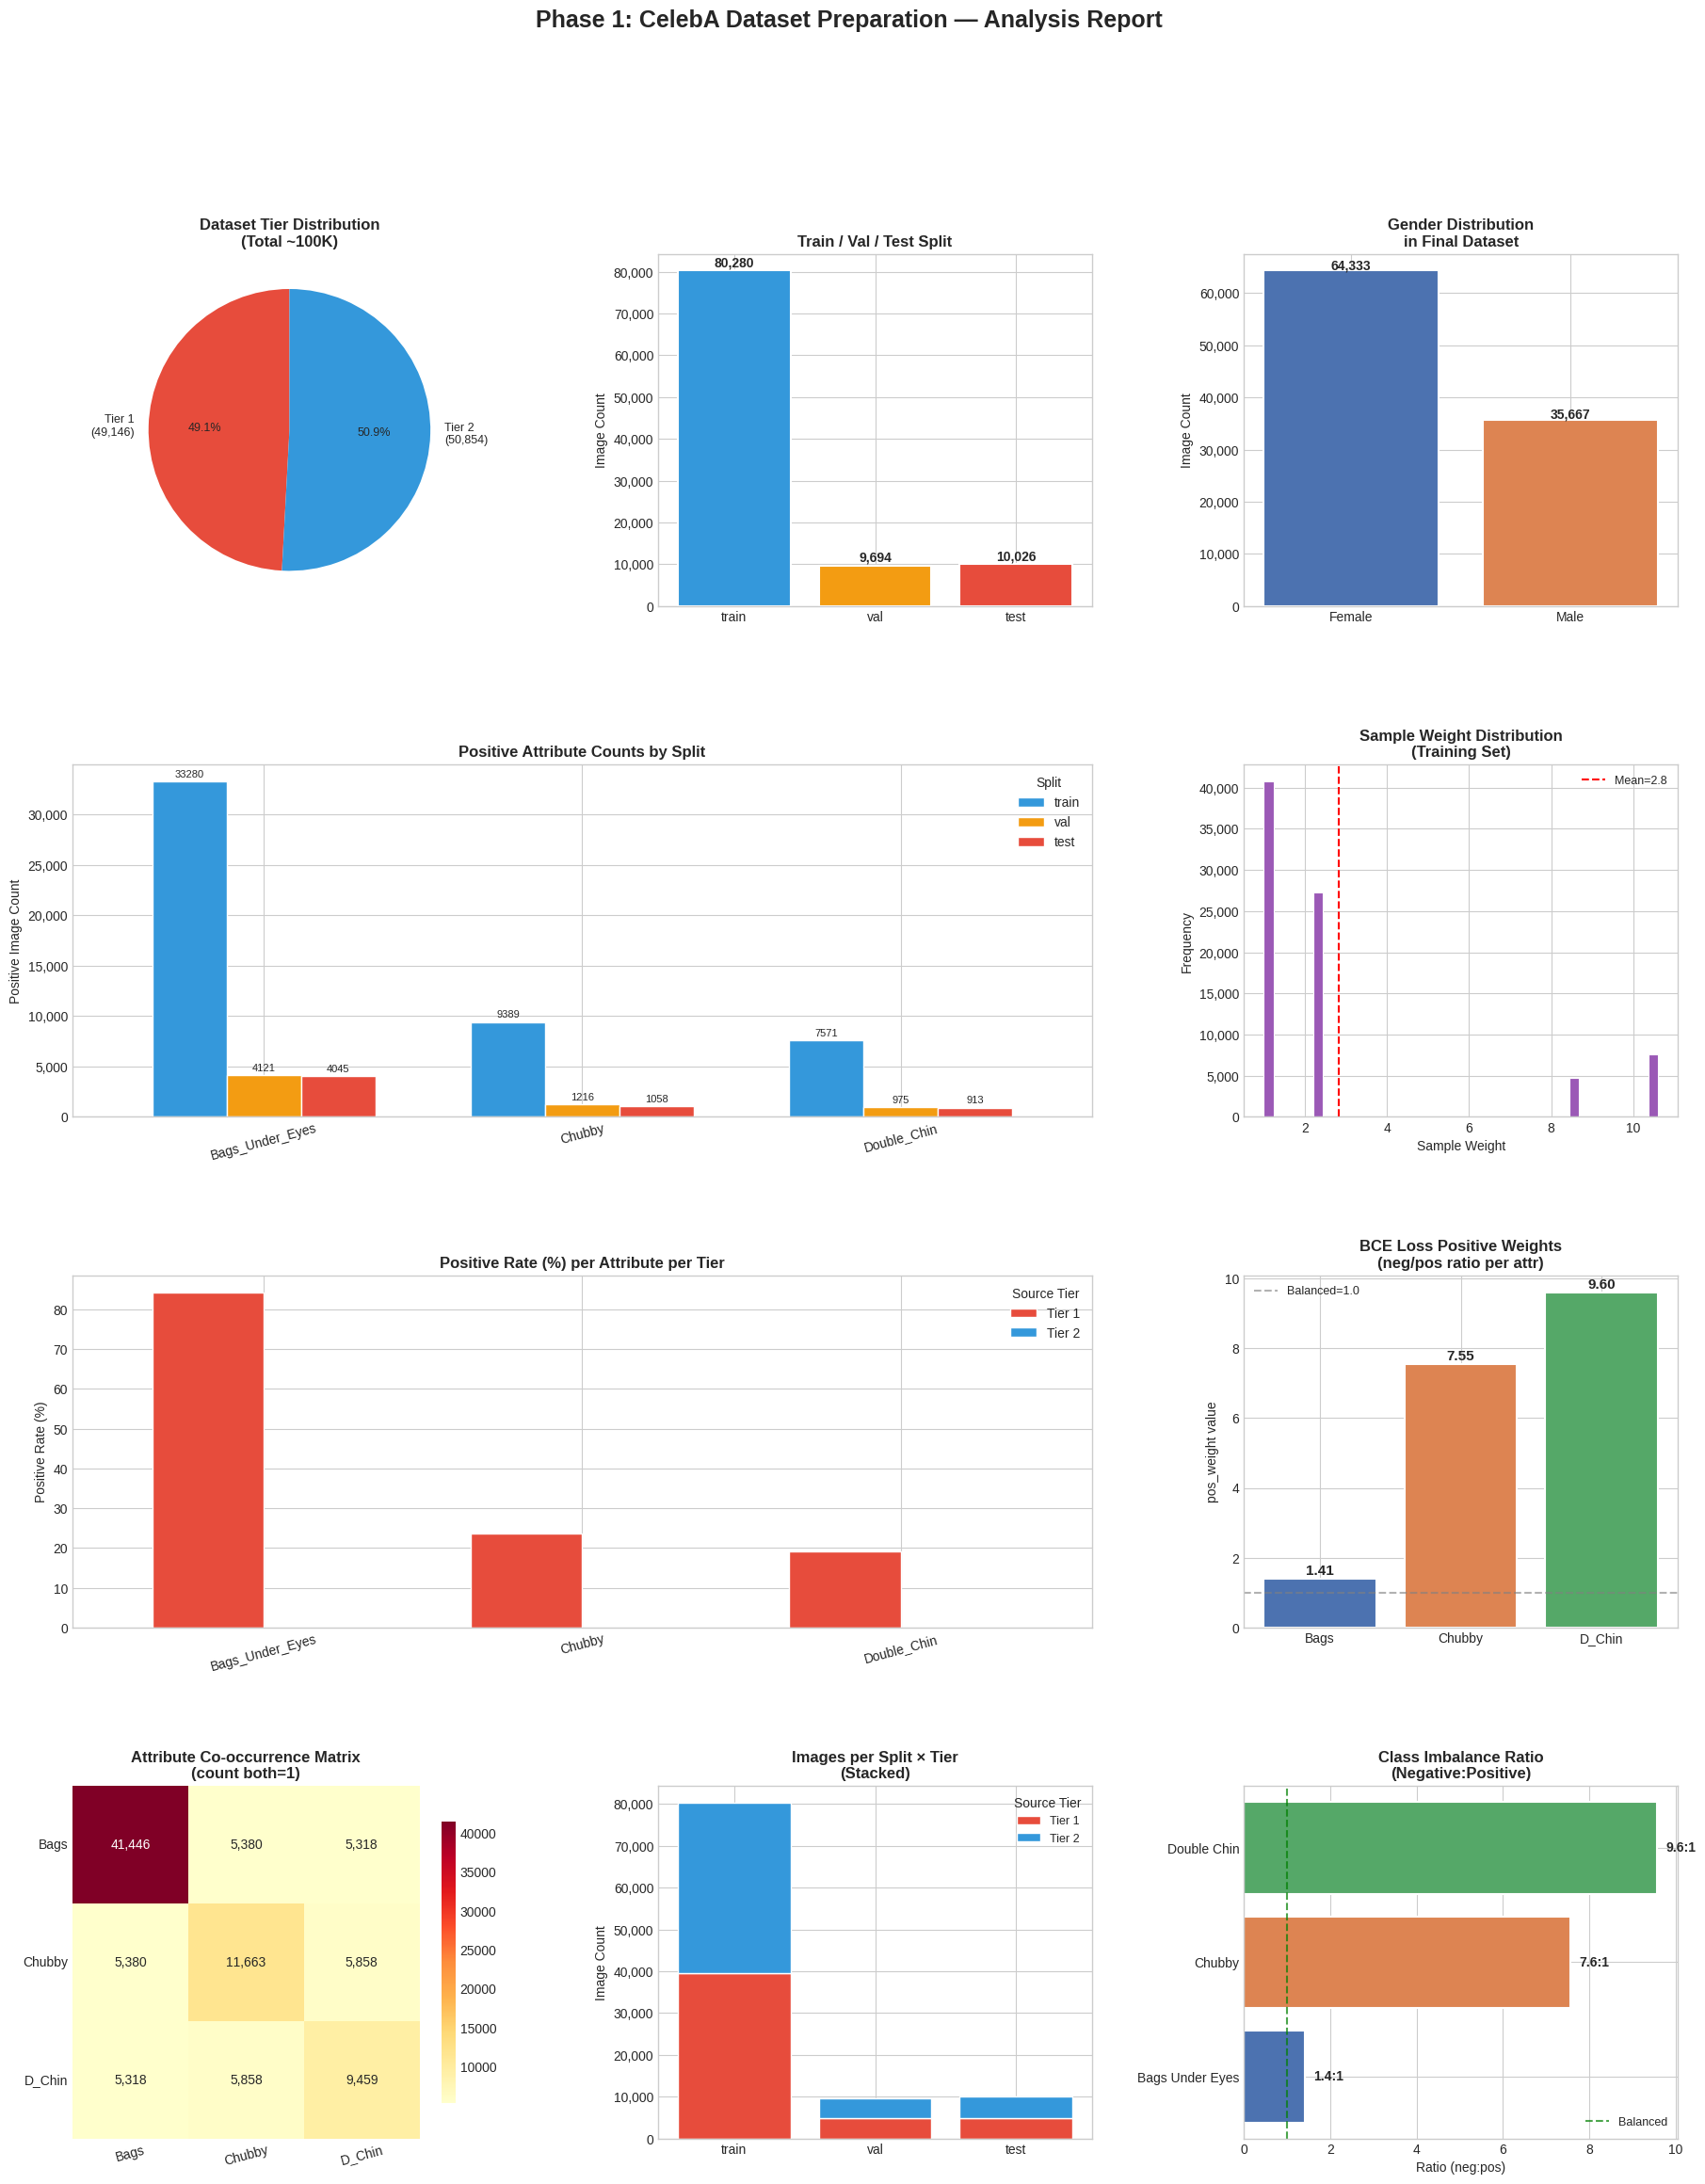

✓ Visualization saved → phase1_analysis.png


In [10]:
# ============================================================
# CELL 10: COMPREHENSIVE PHASE 1 VISUALIZATIONS
# ============================================================

plt.style.use("seaborn-v0_8-whitegrid")
PALETTE = {
    "Bags_Under_Eyes" : "#4C72B0",
    "Chubby"          : "#DD8452",
    "Double_Chin"     : "#55A868",
    "Male"            : "#4C72B0",
    "Female"          : "#DD8452",
}

fig = plt.figure(figsize=(22, 26))
fig.suptitle(
    "Phase 1: CelebA Dataset Preparation — Analysis Report",
    fontsize=18, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(4, 3, figure=fig,
                        hspace=0.45, wspace=0.35)

# ── PLOT 1: Tier distribution (pie) ──────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
tier_counts = manifest["source_tier"].value_counts().sort_index()
tier_labels = [f"Tier {i}\n({v:,})" for i, v in
               tier_counts.items()]
colors_pie  = ["#E74C3C", "#3498DB", "#2ECC71"][:len(tier_counts)]
ax1.pie(tier_counts.values, labels=tier_labels,
        colors=colors_pie, autopct="%1.1f%%",
        startangle=90, textprops={"fontsize": 9})
ax1.set_title("Dataset Tier Distribution\n(Total ~100K)",
              fontweight="bold")

# ── PLOT 2: Split distribution (bar) ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
split_counts = manifest["split"].value_counts()
split_order  = ["train", "val", "test"]
vals = [split_counts.get(s, 0) for s in split_order]
bars = ax2.bar(split_order, vals,
               color=["#3498DB","#F39C12","#E74C3C"],
               edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 300,
             f"{val:,}", ha="center", va="bottom",
             fontsize=10, fontweight="bold")
ax2.set_title("Train / Val / Test Split", fontweight="bold")
ax2.set_ylabel("Image Count")
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)

# ── PLOT 3: Gender distribution ───────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
gender_map   = {1: "Male", -1: "Female"}
gender_cnt   = manifest["gender"].map(gender_map).value_counts()
ax3.bar(gender_cnt.index, gender_cnt.values,
        color=[PALETTE["Male"], PALETTE["Female"]],
        edgecolor="white", linewidth=1.5)
for i, (label, val) in enumerate(gender_cnt.items()):
    ax3.text(i, val + 300, f"{val:,}",
             ha="center", fontsize=10, fontweight="bold")
ax3.set_title("Gender Distribution\nin Final Dataset",
              fontweight="bold")
ax3.set_ylabel("Image Count")
ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)

# ── PLOT 4: Attribute positive counts (grouped by split) ─────
ax4 = fig.add_subplot(gs[1, :2])
attr_split_data = []
for split in ["train", "val", "test"]:
    sub = manifest[manifest["split"] == split]
    for col in TARGET_ATTRS:
        pos = (sub[col] == 1).sum()
        attr_split_data.append({
            "split": split, "attribute": col, "count": pos
        })
df_plot4 = pd.DataFrame(attr_split_data)
df_plot4_pivot = df_plot4.pivot(
    index="attribute", columns="split", values="count"
)
df_plot4_pivot[["train","val","test"]].plot(
    kind="bar", ax=ax4,
    color=["#3498DB","#F39C12","#E74C3C"],
    edgecolor="white", linewidth=1, width=0.7
)
ax4.set_title("Positive Attribute Counts by Split",
              fontweight="bold")
ax4.set_ylabel("Positive Image Count")
ax4.set_xlabel("")
ax4.tick_params(axis="x", rotation=15)
ax4.legend(title="Split", loc="upper right")
ax4.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)
for container in ax4.containers:
    ax4.bar_label(container, fmt="%d", fontsize=8, padding=2)

# ── PLOT 5: Sample weight distribution ───────────────────────
ax5 = fig.add_subplot(gs[1, 2])
train_weights = manifest[manifest["split"] == "train"]["sample_weight"]
ax5.hist(train_weights, bins=40,
         color="#9B59B6", edgecolor="white", linewidth=0.8)
ax5.axvline(train_weights.mean(), color="red",
            linestyle="--", label=f"Mean={train_weights.mean():.1f}")
ax5.set_title("Sample Weight Distribution\n(Training Set)",
              fontweight="bold")
ax5.set_xlabel("Sample Weight")
ax5.set_ylabel("Frequency")
ax5.legend(fontsize=9)
ax5.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)

# ── PLOT 6: Positive rate per attribute per tier ──────────────
ax6 = fig.add_subplot(gs[2, :2])
tier_attr_data = []
for tier in sorted(manifest["source_tier"].unique()):
    sub = manifest[manifest["source_tier"] == tier]
    for col in TARGET_ATTRS:
        rate = (sub[col] == 1).mean() * 100
        tier_attr_data.append({
            "Tier": f"Tier {tier}",
            "Attribute": col,
            "Positive Rate (%)": rate
        })
df_plot6 = pd.DataFrame(tier_attr_data)
df_plot6_pivot = df_plot6.pivot(
    index="Attribute", columns="Tier",
    values="Positive Rate (%)"
)
df_plot6_pivot.plot(kind="bar", ax=ax6,
                    color=["#E74C3C","#3498DB","#2ECC71"],
                    edgecolor="white", linewidth=1, width=0.7)
ax6.set_title("Positive Rate (%) per Attribute per Tier",
              fontweight="bold")
ax6.set_ylabel("Positive Rate (%)")
ax6.set_xlabel("")
ax6.tick_params(axis="x", rotation=15)
ax6.legend(title="Source Tier")

# ── PLOT 7: BCE positive weights bar ─────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
pw_names  = list(pos_weights.keys())
pw_vals   = list(pos_weights.values())
short_names = ["Bags", "Chubby", "D_Chin"]
bars7 = ax7.bar(short_names, pw_vals,
                color=list(PALETTE.values())[:3],
                edgecolor="white", linewidth=1.5)
for bar, val in zip(bars7, pw_vals):
    ax7.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f"{val:.2f}", ha="center",
             fontsize=11, fontweight="bold")
ax7.set_title("BCE Loss Positive Weights\n(neg/pos ratio per attr)",
              fontweight="bold")
ax7.set_ylabel("pos_weight value")
ax7.axhline(1.0, color="gray", linestyle="--",
            alpha=0.6, label="Balanced=1.0")
ax7.legend(fontsize=9)

# ── PLOT 8: Co-occurrence heatmap ────────────────────────────
ax8 = fig.add_subplot(gs[3, 0])
# Build co-occurrence matrix
comat = pd.DataFrame(0, index=TARGET_ATTRS, columns=TARGET_ATTRS)
df_pos_only = manifest[TARGET_ATTRS].replace(-1, 0)
comat_vals  = df_pos_only.T.dot(df_pos_only)
sns.heatmap(comat_vals, ax=ax8, annot=True, fmt=",d",
            cmap="YlOrRd",
            xticklabels=["Bags","Chubby","D_Chin"],
            yticklabels=["Bags","Chubby","D_Chin"],
            cbar_kws={"shrink": 0.8})
ax8.set_title("Attribute Co-occurrence Matrix\n(count both=1)",
              fontweight="bold")
ax8.tick_params(axis="x", rotation=15)
ax8.tick_params(axis="y", rotation=0)

# ── PLOT 9: Images per split per tier (stacked bar) ───────────
ax9 = fig.add_subplot(gs[3, 1])
tiers   = sorted(manifest["source_tier"].unique())
splits  = ["train", "val", "test"]
tier_split = {}
for t in tiers:
    sub = manifest[manifest["source_tier"] == t]
    tier_split[f"Tier {t}"] = [
        (sub["split"] == s).sum() for s in splits
    ]

bottom = np.zeros(3)
colors_stacked = ["#E74C3C","#3498DB","#2ECC71"]
for i, (label, vals_) in enumerate(tier_split.items()):
    ax9.bar(splits, vals_, bottom=bottom,
            label=label, color=colors_stacked[i],
            edgecolor="white", linewidth=1)
    bottom += np.array(vals_)

ax9.set_title("Images per Split × Tier\n(Stacked)",
              fontweight="bold")
ax9.set_ylabel("Image Count")
ax9.legend(title="Source Tier", fontsize=9)
ax9.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)

# ── PLOT 10: Attribute imbalance ratio (final dataset) ────────
ax10 = fig.add_subplot(gs[3, 2])
ratios = []
labels_ = []
for col in TARGET_ATTRS:
    n_pos = (manifest[col] ==  1).sum()
    n_neg = (manifest[col] == -1).sum()
    ratios.append(n_neg / n_pos)
    labels_.append(col.replace("_"," "))

colors10 = [PALETTE["Bags_Under_Eyes"],
            PALETTE["Chubby"],
            PALETTE["Double_Chin"]]
bars10 = ax10.barh(labels_, ratios, color=colors10,
                   edgecolor="white", linewidth=1.5)
for bar, val in zip(bars10, ratios):
    ax10.text(val + 0.2, bar.get_y() + bar.get_height()/2,
              f"{val:.1f}:1", va="center",
              fontsize=10, fontweight="bold")
ax10.set_title("Class Imbalance Ratio\n(Negative:Positive)",
               fontweight="bold")
ax10.set_xlabel("Ratio (neg:pos)")
ax10.axvline(1.0, color="green", linestyle="--",
             alpha=0.7, label="Balanced")
ax10.legend(fontsize=9)

plt.savefig(OUTPUT_DIR / "phase1_analysis.png",
            dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("✓ Visualization saved → phase1_analysis.png")

In [11]:
# ============================================================
# CELL 11: FINAL SUMMARY REPORT
# ============================================================

print("=" * 65)
print("  PHASE 1 COMPLETE — FINAL SUMMARY REPORT")
print("=" * 65)

print(f"""
  DATASET COMPOSITION
  ───────────────────────────────────────────────────────────
  Total Images Selected        : {len(manifest):>8,}
  ├── Tier 1 (≥1 attr +1)     : {(manifest['source_tier']==1).sum():>8,}  ({(manifest['source_tier']==1).mean()*100:.1f}%)
  ├── Tier 2 (female neg/uns)  : {(manifest['source_tier']==2).sum():>8,}  ({(manifest['source_tier']==2).mean()*100:.1f}%)
  └── Tier 3 (male fill)       : {(manifest['source_tier']==3).sum():>8,}  ({(manifest['source_tier']==3).mean()*100:.1f}%)

  TRAIN / VAL / TEST SPLIT
  ───────────────────────────────────────────────────────────
  Train                        : {(manifest['split']=='train').sum():>8,}  ({(manifest['split']=='train').mean()*100:.1f}%)
  Val                          : {(manifest['split']=='val').sum():>8,}  ({(manifest['split']=='val').mean()*100:.1f}%)
  Test                         : {(manifest['split']=='test').sum():>8,}  ({(manifest['split']=='test').mean()*100:.1f}%)

  GENDER BREAKDOWN
  ───────────────────────────────────────────────────────────
  Male   (+1)                  : {(manifest['gender']==1).sum():>8,}  ({(manifest['gender']==1).mean()*100:.1f}%)
  Female (-1)                  : {(manifest['gender']==-1).sum():>8,}  ({(manifest['gender']==-1).mean()*100:.1f}%)

  POSITIVE ATTRIBUTE COUNTS (FULL DATASET)
  ───────────────────────────────────────────────────────────
  Bags_Under_Eyes              : {(manifest['Bags_Under_Eyes']==1).sum():>8,}  ({(manifest['Bags_Under_Eyes']==1).mean()*100:.2f}%)
  Chubby                       : {(manifest['Chubby']==1).sum():>8,}  ({(manifest['Chubby']==1).mean()*100:.2f}%)
  Double_Chin                  : {(manifest['Double_Chin']==1).sum():>8,}  ({(manifest['Double_Chin']==1).mean()*100:.2f}%)

  BCE LOSS POSITIVE WEIGHTS (computed on train split)
  ───────────────────────────────────────────────────────────
  Bags_Under_Eyes pos_weight   : {pos_weights['Bags_Under_Eyes']:>8.2f}
  Chubby          pos_weight   : {pos_weights['Chubby']:>8.2f}
  Double_Chin     pos_weight   : {pos_weights['Double_Chin']:>8.2f}

  OUTPUT FILES
  ───────────────────────────────────────────────────────────
  Manifest CSV                 : {str(MANIFEST_PATH)}
  Stats JSON                   : {str(STATS_PATH)}
  Visualization PNG            : {str(OUTPUT_DIR/'phase1_analysis.png')}
""")

print("  NEXT STEP → Phase 2: MediaPipe Feature Extraction")
print("              Input: manifest.csv")
print("              Output: .npy files + updated manifest")
print("=" * 65)

  PHASE 1 COMPLETE — FINAL SUMMARY REPORT

  DATASET COMPOSITION
  ───────────────────────────────────────────────────────────
  Total Images Selected        :  100,000
  ├── Tier 1 (≥1 attr +1)     :   49,146  (49.1%)
  ├── Tier 2 (female neg/uns)  :   50,854  (50.9%)
  └── Tier 3 (male fill)       :        0  (0.0%)

  TRAIN / VAL / TEST SPLIT
  ───────────────────────────────────────────────────────────
  Train                        :   80,280  (80.3%)
  Val                          :    9,694  (9.7%)
  Test                         :   10,026  (10.0%)

  GENDER BREAKDOWN
  ───────────────────────────────────────────────────────────
  Male   (+1)                  :   35,667  (35.7%)
  Female (-1)                  :   64,333  (64.3%)

  POSITIVE ATTRIBUTE COUNTS (FULL DATASET)
  ───────────────────────────────────────────────────────────
  Bags_Under_Eyes              :   41,446  (41.45%)
  Chubby                       :   11,663  (11.66%)
  Double_Chin                  :    9,459  (

# phase2

In [12]:
# ============================================================
# CELL 12: CREATE MODULE DIRECTORY STRUCTURE
# ============================================================

import os
import sys
from pathlib import Path

# ── Create src/ and feature output directories ───────────────
SRC_DIR      = Path("/kaggle/working/src")
FEATURE_DIR  = Path("/kaggle/working/mediapipe_features")
LOG_DIR      = Path("/kaggle/working/logs")

for d in [SRC_DIR, FEATURE_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"  ✓ Created / verified: {d}")

# ── Add src/ to Python path so we can import modules ─────────
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
    sys.path.insert(0, "/kaggle/working")

print(f"\n  Python path updated ✓")
print(f"  sys.path[0:3]: {sys.path[:3]}")

  ✓ Created / verified: /kaggle/working/src
  ✓ Created / verified: /kaggle/working/mediapipe_features
  ✓ Created / verified: /kaggle/working/logs

  Python path updated ✓
  sys.path[0:3]: ['/kaggle/working', '/kaggle/working/src', '/kaggle/working']


In [13]:
# ============================================================
# CELL 13: WRITE src/landmark_config.py
# ============================================================
# This module holds ALL landmark IDs and feature definitions
# Centralised here so any change propagates to all other modules
# ============================================================

landmark_config_code = '''
"""
landmark_config.py
──────────────────
MediaPipe FaceMesh landmark indices and feature group
definitions for the three target attributes:
  - Bags_Under_Eyes
  - Chubby
  - Double_Chin

MediaPipe FaceMesh produces 478 landmarks (x, y, z)
normalised to [0,1] relative to image width/height.
z is relative depth (smaller = closer to camera).

All indices verified against:
  MediaPipe Face Mesh topology map (2023)
  https://github.com/google/mediapipe/blob/master/
  mediapipe/modules/face_geometry/data/canonical_face_model_uv_visualization.png
"""

# ── Under-Eye Region ─────────────────────────────────────────
# Lower eyelid & infraorbital region
LEFT_LOWER_LID   = [246, 161, 160, 159, 158, 157, 173]
RIGHT_LOWER_LID  = [466, 388, 387, 386, 385, 384, 398]

# Infraorbital (under-eye fat pad region)
LEFT_INFRAORBIT  = [116, 123, 147, 213, 192, 214]
RIGHT_INFRAORBIT = [345, 352, 376, 433, 411, 434]

# Eye inner/outer corners (for width normalisation)
LEFT_EYE_INNER   = 133   # medial canthus left
LEFT_EYE_OUTER   = 33    # lateral canthus left
RIGHT_EYE_INNER  = 362   # medial canthus right
RIGHT_EYE_OUTER  = 263   # lateral canthus right

# ── Cheek & Face Width Region ────────────────────────────────
# Cheek landmarks for fullness estimation
LEFT_CHEEK       = [116, 117, 118, 119, 120, 121, 128]
RIGHT_CHEEK      = [345, 346, 347, 348, 349, 350, 357]

# Face width reference points
FACE_LEFT_EDGE   = 234   # left face boundary
FACE_RIGHT_EDGE  = 454   # right face boundary

# ── Jaw & Chin Region ────────────────────────────────────────
# Jaw contour landmarks
JAW_LEFT         = [172, 136, 150, 149, 176, 148, 152]
JAW_RIGHT        = [397, 365, 379, 378, 400, 377, 152]

# Chin landmarks
CHIN_CENTER      = 152   # lowest chin point
CHIN_TIP         = 175   # chin tip
MENTON           = 18    # bottom of lower lip / top of chin

# Submental region (under chin — key for double chin)
SUBMENTAL        = [175, 18, 200, 199, 175]

# ── Nose Reference (for normalisation) ───────────────────────
NOSE_TIP         = 1
NOSE_BRIDGE      = 6
NOSE_BASE        = 2

# ── Forehead Reference ───────────────────────────────────────
FOREHEAD_TOP     = 10    # top of face

# ── Lip Landmarks ─────────────────────────────────────────────
UPPER_LIP        = 13
LOWER_LIP        = 14
MOUTH_CENTER     = 17

# ════════════════════════════════════════════════════════════
# FEATURE DEFINITIONS
# Each entry: (name, computation_type, landmark_args)
# computation_type:
#   "dist"   → Euclidean distance between two landmarks
#   "ratio"  → dist_A / dist_B  (scale-invariant)
#   "angle"  → angle at vertex landmark (3 points)
#   "depth"  → z-coordinate difference (depth proxy)
#   "mean_y" → mean Y of landmark group (vertical position)
# ════════════════════════════════════════════════════════════

FEATURE_DEFINITIONS = [
    # ── Bags Under Eyes Features (indices 0-5) ───────────────
    {
        "name"  : "left_infraorbital_depth",
        "type"  : "depth",
        "desc"  : "Z-depth of left under-eye region vs eye center",
        "lmks"  : (LEFT_INFRAORBIT, LEFT_LOWER_LID),
        "attr"  : "Bags_Under_Eyes",
    },
    {
        "name"  : "right_infraorbital_depth",
        "type"  : "depth",
        "desc"  : "Z-depth of right under-eye region vs eye center",
        "lmks"  : (RIGHT_INFRAORBIT, RIGHT_LOWER_LID),
        "attr"  : "Bags_Under_Eyes",
    },
    {
        "name"  : "left_eye_bag_ratio",
        "type"  : "ratio",
        "desc"  : "Under-eye region height / eye width (left)",
        "lmks"  : (160, 159, LEFT_EYE_INNER, LEFT_EYE_OUTER),
        "attr"  : "Bags_Under_Eyes",
    },
    {
        "name"  : "right_eye_bag_ratio",
        "type"  : "ratio",
        "desc"  : "Under-eye region height / eye width (right)",
        "lmks"  : (386, 385, RIGHT_EYE_INNER, RIGHT_EYE_OUTER),
        "attr"  : "Bags_Under_Eyes",
    },
    {
        "name"  : "left_cheek_eye_dist_ratio",
        "type"  : "ratio",
        "desc"  : "Cheek top to lower lid / face height",
        "lmks"  : (LEFT_INFRAORBIT[0], CHIN_CENTER,
                   FOREHEAD_TOP, CHIN_CENTER),
        "attr"  : "Bags_Under_Eyes",
    },
    {
        "name"  : "right_cheek_eye_dist_ratio",
        "type"  : "ratio",
        "desc"  : "Cheek top to lower lid / face height (right)",
        "lmks"  : (RIGHT_INFRAORBIT[0], CHIN_CENTER,
                   FOREHEAD_TOP, CHIN_CENTER),
        "attr"  : "Bags_Under_Eyes",
    },

    # ── Chubby / Face Fullness Features (indices 6-11) ───────
    {
        "name"  : "face_width_height_ratio",
        "type"  : "ratio",
        "desc"  : "Face width / face height (chubby proxy)",
        "lmks"  : (FACE_LEFT_EDGE, FACE_RIGHT_EDGE,
                   FOREHEAD_TOP, CHIN_CENTER),
        "attr"  : "Chubby",
    },
    {
        "name"  : "left_cheek_fullness",
        "type"  : "ratio",
        "desc"  : "Left cheek protrusion / half face width",
        "lmks"  : (LEFT_CHEEK[3], NOSE_TIP,
                   FACE_LEFT_EDGE, FACE_RIGHT_EDGE),
        "attr"  : "Chubby",
    },
    {
        "name"  : "right_cheek_fullness",
        "type"  : "ratio",
        "desc"  : "Right cheek protrusion / half face width",
        "lmks"  : (RIGHT_CHEEK[3], NOSE_TIP,
                   FACE_LEFT_EDGE, FACE_RIGHT_EDGE),
        "attr"  : "Chubby",
    },
    {
        "name"  : "bigonial_nasal_ratio",
        "type"  : "ratio",
        "desc"  : "Jaw width / nasal width (roundness index)",
        "lmks"  : (FACE_LEFT_EDGE, FACE_RIGHT_EDGE,
                   LEFT_EYE_INNER, RIGHT_EYE_INNER),
        "attr"  : "Chubby",
    },
    {
        "name"  : "cheek_depth_left",
        "type"  : "depth",
        "desc"  : "Z-depth of left cheek vs nose tip",
        "lmks"  : (LEFT_CHEEK, [NOSE_TIP]),
        "attr"  : "Chubby",
    },
    {
        "name"  : "cheek_depth_right",
        "type"  : "depth",
        "desc"  : "Z-depth of right cheek vs nose tip",
        "lmks"  : (RIGHT_CHEEK, [NOSE_TIP]),
        "attr"  : "Chubby",
    },

    # ── Double Chin Features (indices 12-17) ─────────────────
    {
        "name"  : "chin_to_lip_ratio",
        "type"  : "ratio",
        "desc"  : "Chin length (lip→chin) / face height",
        "lmks"  : (LOWER_LIP, CHIN_CENTER,
                   FOREHEAD_TOP, CHIN_CENTER),
        "attr"  : "Double_Chin",
    },
    {
        "name"  : "submental_depth",
        "type"  : "depth",
        "desc"  : "Z-depth under chin vs lip (fat pad proxy)",
        "lmks"  : ([CHIN_CENTER, MENTON], [UPPER_LIP, LOWER_LIP]),
        "attr"  : "Double_Chin",
    },
    {
        "name"  : "jaw_angle_left",
        "type"  : "angle",
        "desc"  : "Jaw angle at left gonion",
        "lmks"  : (172, 136, 150),
        "attr"  : "Double_Chin",
    },
    {
        "name"  : "jaw_angle_right",
        "type"  : "angle",
        "desc"  : "Jaw angle at right gonion",
        "lmks"  : (397, 365, 379),
        "attr"  : "Double_Chin",
    },
    {
        "name"  : "chin_jaw_width_ratio",
        "type"  : "ratio",
        "desc"  : "Chin width / jaw width",
        "lmks"  : (JAW_LEFT[0], JAW_RIGHT[0],
                   FACE_LEFT_EDGE, FACE_RIGHT_EDGE),
        "attr"  : "Double_Chin",
    },
    {
        "name"  : "menton_nose_ratio",
        "type"  : "ratio",
        "desc"  : "Chin prominence vs nose-to-forehead dist",
        "lmks"  : (MENTON, CHIN_CENTER,
                   NOSE_TIP, FOREHEAD_TOP),
        "attr"  : "Double_Chin",
    },
]

# Total features
N_FEATURES     = len(FEATURE_DEFINITIONS)   # 18
FEATURE_NAMES  = [f["name"] for f in FEATURE_DEFINITIONS]
'''

with open(SRC_DIR / "landmark_config.py", "w") as f:
    f.write(landmark_config_code)

print("✓ landmark_config.py written")
print(f"  Path: {SRC_DIR / 'landmark_config.py'}")

✓ landmark_config.py written
  Path: /kaggle/working/src/landmark_config.py


In [14]:
# ============================================================
# CELL 14: WRITE src/feature_utils.py
# ============================================================
# Pure geometric computation functions
# All functions are stateless — input landmarks, output scalar
# ============================================================

feature_utils_code = '''
"""
feature_utils.py
────────────────
Stateless geometric computation utilities.
All functions take MediaPipe landmark objects or
pre-extracted numpy arrays and return float scalars.

Coordinate convention (MediaPipe normalised):
  x → [0,1] horizontal (left=0, right=1)
  y → [0,1] vertical   (top=0, bottom=1)
  z → relative depth   (negative = closer to camera)
"""

import numpy as np
from typing import List, Union


# ── Type alias ────────────────────────────────────────────────
LandmarkList = list   # list of mediapipe NormalizedLandmark


def lmk_to_arr(landmark) -> np.ndarray:
    """Convert single MediaPipe landmark to (x,y,z) numpy array."""
    return np.array([landmark.x, landmark.y, landmark.z],
                    dtype=np.float32)


def lmks_to_arr(landmarks, indices: List[int]) -> np.ndarray:
    """
    Extract subset of landmarks by index list.
    Returns shape: (len(indices), 3)
    """
    return np.array(
        [[landmarks[i].x, landmarks[i].y, landmarks[i].z]
         for i in indices],
        dtype=np.float32
    )


def group_mean(landmarks, indices: List[int]) -> np.ndarray:
    """
    Compute mean (x,y,z) of a group of landmarks.
    Returns shape: (3,)
    """
    pts = lmks_to_arr(landmarks, indices)
    return pts.mean(axis=0)


def euclidean_dist_2d(p1: np.ndarray, p2: np.ndarray) -> float:
    """
    2D Euclidean distance (x,y only, ignoring depth).
    Scale-invariant when coordinates are normalised.
    """
    return float(np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2))


def euclidean_dist_3d(p1: np.ndarray, p2: np.ndarray) -> float:
    """3D Euclidean distance including z (depth)."""
    return float(np.linalg.norm(p1 - p2))


def safe_ratio(numerator: float,
               denominator: float,
               fallback: float = 0.0,
               eps: float = 1e-6) -> float:
    """
    Compute numerator/denominator safely.
    Returns fallback if denominator is near zero.
    """
    if abs(denominator) < eps:
        return fallback
    return float(numerator / denominator)


def compute_dist_feature(landmarks,
                          idx_a: int,
                          idx_b: int) -> float:
    """
    Euclidean 2D distance between two landmark indices.
    Used as a raw distance feature.
    """
    p1 = lmk_to_arr(landmarks[idx_a])
    p2 = lmk_to_arr(landmarks[idx_b])
    return euclidean_dist_2d(p1, p2)


def compute_ratio_feature(landmarks,
                           num_a: int,
                           num_b: int,
                           den_a: int,
                           den_b: int) -> float:
    """
    Ratio of two distances:
      dist(num_a, num_b) / dist(den_a, den_b)

    All inputs are landmark indices (single ints).
    This produces a scale-invariant feature.
    """
    p_na = lmk_to_arr(landmarks[num_a])
    p_nb = lmk_to_arr(landmarks[num_b])
    p_da = lmk_to_arr(landmarks[den_a])
    p_db = lmk_to_arr(landmarks[den_b])

    numerator   = euclidean_dist_2d(p_na, p_nb)
    denominator = euclidean_dist_2d(p_da, p_db)
    return safe_ratio(numerator, denominator)


def compute_group_ratio_feature(landmarks,
                                 group_num: List[int],
                                 group_den: List[int]) -> float:
    """
    Ratio of distances between GROUP centroids.
    dist(centroid(group_num[0]), centroid(group_num[1])) /
    dist(centroid(group_den[0]), centroid(group_den[1]))

    Used when we pass lists of landmark indices.
    """
    # Each group arg can be a list or single int
    def get_centroid(g):
        if isinstance(g, (list, tuple)):
            return group_mean(landmarks, g)
        else:
            return lmk_to_arr(landmarks[g])

    # group_num and group_den each have 2 elements
    # representing (point_A, point_B) for numerator / denominator
    num_a, num_b = group_num[0], group_num[1]
    den_a, den_b = group_den[0], group_den[1]

    c_na = get_centroid(num_a)
    c_nb = get_centroid(num_b)
    c_da = get_centroid(den_a)
    c_db = get_centroid(den_b)

    numerator   = euclidean_dist_2d(c_na, c_nb)
    denominator = euclidean_dist_2d(c_da, c_db)
    return safe_ratio(numerator, denominator)


def compute_depth_feature(landmarks,
                           group_a: List[int],
                           group_b: List[int]) -> float:
    """
    Depth difference between two groups of landmarks.
    depth_diff = mean_z(group_a) - mean_z(group_b)

    Positive → group_a is further from camera than group_b.
    Negative → group_a is closer (raised, puffy region).

    z convention in MediaPipe: smaller z = closer to camera.
    Puffiness (bags) → lower z (closer to camera) for
    infraorbital region compared to surrounding landmarks.
    """
    def get_mean_z(g):
        if isinstance(g, (list, tuple)):
            pts = lmks_to_arr(landmarks, g)
            return float(pts[:, 2].mean())
        else:
            return float(landmarks[g].z)

    z_a = get_mean_z(group_a)
    z_b = get_mean_z(group_b)
    return z_a - z_b


def compute_angle_feature(landmarks,
                            v1_idx: int,
                            vertex_idx: int,
                            v2_idx: int) -> float:
    """
    Angle at vertex_idx formed by vectors:
      (v1_idx → vertex_idx) and (v2_idx → vertex_idx)

    Returns angle in degrees [0, 180].
    Smaller jaw angle → more defined jaw → less double chin.
    """
    p1     = lmk_to_arr(landmarks[v1_idx])
    vertex = lmk_to_arr(landmarks[vertex_idx])
    p2     = lmk_to_arr(landmarks[v2_idx])

    # Vectors from vertex
    vec1 = p1[:2] - vertex[:2]   # use 2D only
    vec2 = p2[:2] - vertex[:2]

    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    if norm1 < 1e-8 or norm2 < 1e-8:
        return 0.0

    cos_angle = np.clip(
        np.dot(vec1, vec2) / (norm1 * norm2),
        -1.0, 1.0
    )
    angle_deg = float(np.degrees(np.arccos(cos_angle)))
    return angle_deg


def normalise_feature_vector(vec: np.ndarray) -> np.ndarray:
    """
    Normalise a feature vector to [0,1] range using
    min-max scaling per element.
    Note: In practice we use BatchNorm in the model,
    this is a safety clip for extreme outlier values.
    """
    vec = np.clip(vec, -10.0, 10.0)   # clip extreme outliers
    return vec.astype(np.float32)


def build_zero_vector(n_features: int = 18) -> np.ndarray:
    """
    Return a zero vector for failed MediaPipe detections.
    Model uses a mask flag to ignore this vector.
    """
    return np.zeros(n_features, dtype=np.float32)
'''

with open(SRC_DIR / "feature_utils.py", "w") as f:
    f.write(feature_utils_code)

print("✓ feature_utils.py written")
print(f"  Path: {SRC_DIR / 'feature_utils.py'}")

✓ feature_utils.py written
  Path: /kaggle/working/src/feature_utils.py


In [15]:
# ============================================================
# CELL 15 (FIXED): REWRITE src/mediapipe_extractor.py
# Compatible with mediapipe >= 0.10.x (new Tasks API)
# ============================================================

mediapipe_extractor_code = '''
"""
mediapipe_extractor.py
──────────────────────
FaceGeometricExtractor class — compatible with mediapipe >= 0.10.x
Uses the new FaceLandmarker Tasks API (mp.tasks.vision)
instead of the deprecated mp.solutions.face_mesh

mediapipe >= 0.10.0 migration:
  OLD: mp.solutions.face_mesh.FaceMesh()
  NEW: mp.tasks.vision.FaceLandmarker.create_from_options()
"""

import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from mediapipe.tasks.python.vision import FaceLandmarkerOptions
from mediapipe.tasks.python.vision import FaceLandmarker
from mediapipe.tasks.python.core.base_options import BaseOptions

import urllib.request
from pathlib import Path
from typing import Tuple, Optional, Dict
import os

from landmark_config import (
    FEATURE_DEFINITIONS, N_FEATURES, FEATURE_NAMES,
    LEFT_LOWER_LID, RIGHT_LOWER_LID,
    LEFT_INFRAORBIT, RIGHT_INFRAORBIT,
    LEFT_EYE_INNER, LEFT_EYE_OUTER,
    RIGHT_EYE_INNER, RIGHT_EYE_OUTER,
    LEFT_CHEEK, RIGHT_CHEEK,
    JAW_LEFT, JAW_RIGHT,
)
from feature_utils import (
    compute_ratio_feature,
    compute_depth_feature,
    compute_angle_feature,
    normalise_feature_vector,
    build_zero_vector,
    lmk_to_arr,
    group_mean,
    euclidean_dist_2d,
    safe_ratio,
)

# ── Model file path (downloaded once) ────────────────────────
MODEL_PATH = "/kaggle/working/face_landmarker.task"
MODEL_URL  = (
    "https://storage.googleapis.com/mediapipe-models/"
    "face_landmarker/face_landmarker/float16/1/face_landmarker.task"
)


def download_model(model_path: str = MODEL_PATH,
                   model_url:  str = MODEL_URL) -> str:
    """
    Download MediaPipe FaceLandmarker .task model file
    if not already present.
    Returns path to model file.
    """
    if Path(model_path).exists():
        print(f"  Model already exists: {model_path}")
        return model_path

    print(f"  Downloading FaceLandmarker model...")
    print(f"  URL: {model_url}")
    urllib.request.urlretrieve(model_url, model_path)
    size_mb = Path(model_path).stat().st_size / 1024 / 1024
    print(f"  Downloaded: {size_mb:.1f} MB → {model_path}")
    return model_path


class LandmarkWrapper:
    """
    Wraps mediapipe NormalizedLandmark from Tasks API
    to provide .x .y .z attribute access — same interface
    as the old solutions API so feature_utils works unchanged.
    """
    def __init__(self, x: float, y: float, z: float):
        self.x = x
        self.y = y
        self.z = z


class LandmarkListWrapper:
    """
    Wraps a list of LandmarkWrapper objects to support
    index access: landmarks[i] → LandmarkWrapper
    """
    def __init__(self, landmark_list):
        self._lmks = landmark_list

    def __getitem__(self, idx: int) -> LandmarkWrapper:
        lmk = self._lmks[idx]
        return LandmarkWrapper(lmk.x, lmk.y, lmk.z)

    def __len__(self):
        return len(self._lmks)


class FaceGeometricExtractor:
    """
    Extracts 18 scale-invariant geometric features from a face
    image using MediaPipe FaceLandmarker (Tasks API).

    Compatible with mediapipe >= 0.10.x

    Usage:
        extractor = FaceGeometricExtractor()
        features, success = extractor.extract(image_path)
        # features.shape == (18,)  dtype=float32
        # success == True if face detected

    Thread Safety:
        NOT thread-safe — one instance per worker process.
    """

    def __init__(self,
                 model_path: str = MODEL_PATH,
                 min_face_detection_confidence: float = 0.5,
                 min_face_presence_confidence:  float = 0.5,
                 min_tracking_confidence:       float = 0.5):

        # Download model if needed
        model_path = download_model(model_path)

        # ── Build FaceLandmarker options (Tasks API) ──────────
        base_options = BaseOptions(
            model_asset_path=model_path
        )

        options = FaceLandmarkerOptions(
            base_options                    = base_options,
            output_face_blendshapes         = False,
            output_facial_transformation_matrixes = False,
            num_faces                       = 1,
            min_face_detection_confidence   = min_face_detection_confidence,
            min_face_presence_confidence    = min_face_presence_confidence,
            min_tracking_confidence         = min_tracking_confidence,
            running_mode                    = mp.tasks.vision.RunningMode.IMAGE,
        )

        self.detector   = FaceLandmarker.create_from_options(options)
        self.n_features = N_FEATURES
        self.feat_names = FEATURE_NAMES

    def _run_detection(self, img_rgb: np.ndarray):
        """
        Run FaceLandmarker on an RGB numpy array.
        Returns raw detection result or None.
        """
        # Convert to MediaPipe Image object
        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=img_rgb
        )
        result = self.detector.detect(mp_image)
        return result

    def _result_to_landmarks(self, result) -> Optional[LandmarkListWrapper]:
        """
        Extract landmark list from detection result.
        Returns LandmarkListWrapper or None if no face found.
        """
        if (result is None or
                not result.face_landmarks or
                len(result.face_landmarks) == 0):
            return None

        # result.face_landmarks[0] is a list of NormalizedLandmark
        return LandmarkListWrapper(result.face_landmarks[0])

    def extract(self,
                image_path: str
                ) -> Tuple[np.ndarray, bool]:
        """
        Extract 18 geometric features from an image file.

        Args:
            image_path: Absolute path to image file.

        Returns:
            features : np.ndarray shape (18,) float32
            success  : bool — False if no face detected
        """
        # ── Load image ────────────────────────────────────────
        img_bgr = cv2.imread(str(image_path))
        if img_bgr is None:
            return build_zero_vector(self.n_features), False

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        return self.extract_from_array(img_rgb)

    def extract_from_array(self,
                            img_rgb: np.ndarray
                            ) -> Tuple[np.ndarray, bool]:
        """
        Extract features directly from an RGB numpy array.
        Used during augmentation (HorizontalFlip).

        Args:
            img_rgb: np.ndarray shape (H, W, 3) uint8 RGB

        Returns:
            features : np.ndarray (18,) float32
            success  : bool
        """
        # Ensure uint8 contiguous array
        if img_rgb.dtype != np.uint8:
            img_rgb = img_rgb.astype(np.uint8)
        if not img_rgb.flags["C_CONTIGUOUS"]:
            img_rgb = np.ascontiguousarray(img_rgb)

        try:
            result    = self._run_detection(img_rgb)
            landmarks = self._result_to_landmarks(result)
        except Exception as e:
            return build_zero_vector(self.n_features), False

        if landmarks is None:
            return build_zero_vector(self.n_features), False

        try:
            features = self._compute_all_features(landmarks)
        except Exception:
            return build_zero_vector(self.n_features), False

        return normalise_feature_vector(features), True

    def _compute_all_features(self,
                               landmarks: LandmarkListWrapper
                               ) -> np.ndarray:
        """
        Compute all 18 features using FEATURE_DEFINITIONS.
        """
        vec = np.zeros(self.n_features, dtype=np.float32)

        for i, fdef in enumerate(FEATURE_DEFINITIONS):
            ftype = fdef["type"]
            lmks  = fdef["lmks"]

            try:
                if ftype == "ratio":
                    vec[i] = self._compute_ratio(landmarks, lmks)
                elif ftype == "depth":
                    vec[i] = self._compute_depth(landmarks, lmks)
                elif ftype == "angle":
                    vec[i] = compute_angle_feature(
                        landmarks, lmks[0], lmks[1], lmks[2]
                    )
                else:
                    vec[i] = 0.0
            except Exception:
                vec[i] = 0.0   # per-feature fallback

        return vec

    def _compute_ratio(self,
                        landmarks: LandmarkListWrapper,
                        lmks) -> float:
        """Dispatch ratio computation (simple or centroid-based)."""
        a, b, c, d = lmks

        if all(isinstance(x, int) for x in [a, b, c, d]):
            return compute_ratio_feature(landmarks, a, b, c, d)

        def get_pt(x):
            if isinstance(x, (list, tuple)):
                return group_mean(landmarks, list(x))
            else:
                return lmk_to_arr(landmarks[x])

        p_a = get_pt(a)
        p_b = get_pt(b)
        p_c = get_pt(c)
        p_d = get_pt(d)

        numerator   = euclidean_dist_2d(p_a, p_b)
        denominator = euclidean_dist_2d(p_c, p_d)
        return safe_ratio(numerator, denominator)

    def _compute_depth(self,
                        landmarks: LandmarkListWrapper,
                        lmks) -> float:
        """Dispatch depth computation."""
        group_a, group_b = lmks
        return compute_depth_feature(landmarks, group_a, group_b)

    def get_feature_names(self):
        return self.feat_names

    def get_n_features(self):
        return self.n_features

    def close(self):
        """Release MediaPipe resources."""
        try:
            self.detector.close()
        except Exception:
            pass

    def __enter__(self):
        return self

    def __exit__(self, *args):
        self.close()


# ── Standalone worker function ─────────────────────────────
# Must be at MODULE LEVEL for multiprocessing pickling

def extract_single_image(args: Tuple) -> Dict:
    """
    Worker function for parallel extraction.
    Creates its own FaceGeometricExtractor instance.

    Args:
        args: (image_id, img_path, output_dir, model_path)

    Returns:
        dict: image_id, npy_path, success, error
    """
    # Unpack — support both 3-arg and 4-arg calls
    if len(args) == 4:
        image_id, img_path, output_dir, model_path = args
    else:
        image_id, img_path, output_dir = args
        model_path = MODEL_PATH

    output_dir   = Path(output_dir)
    npy_filename = Path(image_id).stem + ".npy"
    npy_path     = output_dir / npy_filename

    # Resume support
    if npy_path.exists():
        return {
            "image_id": image_id,
            "npy_path": str(npy_path),
            "success" : True,
            "error"   : "skipped_exists",
        }

    try:
        extractor = FaceGeometricExtractor(model_path=model_path)
        features, success = extractor.extract(img_path)
        extractor.close()

        np.save(str(npy_path), features)

        return {
            "image_id": image_id,
            "npy_path": str(npy_path),
            "success" : success,
            "error"   : "" if success else "no_face_detected",
        }

    except Exception as e:
        np.save(str(npy_path), build_zero_vector())
        return {
            "image_id": image_id,
            "npy_path": str(npy_path),
            "success" : False,
            "error"   : str(e)[:120],
        }
'''

with open(SRC_DIR / "mediapipe_extractor.py", "w") as f:
    f.write(mediapipe_extractor_code)

print("✓ mediapipe_extractor.py rewritten (Tasks API)")
print(f"  Path: {SRC_DIR / 'mediapipe_extractor.py'}")

✓ mediapipe_extractor.py rewritten (Tasks API)
  Path: /kaggle/working/src/mediapipe_extractor.py


In [16]:
# ============================================================
# CELL 16: WRITE src/__init__.py
# ============================================================

init_code = '''
"""
src/ — Modular components for CelebA Attribute Classification
─────────────────────────────────────────────────────────────
Modules:
  landmark_config      → landmark IDs, feature definitions
  feature_utils        → geometric computation functions
  mediapipe_extractor  → FaceGeometricExtractor class
"""

from landmark_config import (
    FEATURE_DEFINITIONS,
    N_FEATURES,
    FEATURE_NAMES,
)

from mediapipe_extractor import (
    FaceGeometricExtractor,
    extract_single_image,
)

from feature_utils import build_zero_vector

__all__ = [
    "FEATURE_DEFINITIONS",
    "N_FEATURES",
    "FEATURE_NAMES",
    "FaceGeometricExtractor",
    "extract_single_image",
    "build_zero_vector",
]
'''

with open(SRC_DIR / "__init__.py", "w") as f:
    f.write(init_code)

print("✓ __init__.py written")
print(f"\n  src/ module structure:")
for f in sorted(SRC_DIR.iterdir()):
    print(f"    {f.name}")

✓ __init__.py written

  src/ module structure:
    __init__.py
    feature_utils.py
    landmark_config.py
    mediapipe_extractor.py


In [17]:
# ============================================================
# CELL 17 (FIXED): INSTALL MEDIAPIPE & VERIFY ALL IMPORTS
# ============================================================

import subprocess
import importlib
import sys

# ── Install correct version ───────────────────────────────────
print("Installing mediapipe (latest compatible)...")

result = subprocess.run(
    ["pip", "install", "mediapipe", "--quiet", "--no-warn-script-location"],
    capture_output=True, text=True
)

print(f"  Exit code: {result.returncode}")

if result.returncode != 0:
    # fallback: try specific available version
    print("  Retrying with explicit version 0.10.21...")
    result = subprocess.run(
        ["pip", "install", "mediapipe==0.10.21",
         "--quiet", "--no-warn-script-location"],
        capture_output=True, text=True
    )
    print(f"  Retry exit code: {result.returncode}")
    if result.returncode != 0:
        print(f"  STDERR: {result.stderr[:400]}")

# ── Force Python to see newly installed package ───────────────
import importlib
import site
importlib.invalidate_caches()

# Reload site packages so new install is discoverable
try:
    import importlib.util
    spec = importlib.util.find_spec("mediapipe")
    print(f"\n  mediapipe found at: {spec.origin if spec else 'NOT FOUND'}")
except Exception as e:
    print(f"  spec check error: {e}")

# ── Verify mediapipe import ───────────────────────────────────
print("\nVerifying module imports...")

try:
    import mediapipe as mp
    print(f"  ✓ mediapipe {mp.__version__}")
    MEDIAPIPE_OK = True
except ImportError as e:
    print(f"  ✗ mediapipe import failed: {e}")
    print("\n  Attempting kernel restart workaround...")
    # On Kaggle, sometimes a fresh import after install needs
    # sys.path to be refreshed manually
    import sys, os
    # Find site-packages
    for path in sys.path:
        if "site-packages" in path:
            print(f"    site-packages: {path}")
    MEDIAPIPE_OK = False

try:
    import cv2
    print(f"  ✓ opencv {cv2.__version__}")
except ImportError as e:
    print(f"  ✗ opencv: {e}")

# ── Reload src modules cleanly ────────────────────────────────
print("\nReloading src modules...")

# Remove cached versions first
for mod_name in ["landmark_config", "feature_utils", "mediapipe_extractor"]:
    if mod_name in sys.modules:
        del sys.modules[mod_name]
        print(f"  Cleared cache: {mod_name}")

# Re-import
try:
    from landmark_config import (
        FEATURE_DEFINITIONS, N_FEATURES, FEATURE_NAMES
    )
    print(f"  ✓ landmark_config  — {N_FEATURES} features defined")
except Exception as e:
    print(f"  ✗ landmark_config: {e}")

try:
    from feature_utils import build_zero_vector, compute_angle_feature
    zv = build_zero_vector(18)
    assert zv.shape == (18,)
    print(f"  ✓ feature_utils   — zero vector shape: {zv.shape}")
except Exception as e:
    print(f"  ✗ feature_utils: {e}")

if MEDIAPIPE_OK:
    try:
        from mediapipe_extractor import (
            FaceGeometricExtractor, extract_single_image
        )
        print(f"  ✓ mediapipe_extractor — classes imported")
    except Exception as e:
        print(f"  ✗ mediapipe_extractor: {e}")
else:
    print("  ⚠ mediapipe_extractor skipped — mediapipe not installed")
    print("\n" + "="*55)
    print("  ACTION REQUIRED:")
    print("  Kaggle sometimes needs a kernel restart after")
    print("  pip install to register new packages.")
    print("  → Click 'Run All' again OR")
    print("  → Menu → Run → Restart & Run All")
    print("="*55)

Installing mediapipe (latest compatible)...
  Exit code: 0

  mediapipe found at: /usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py

Verifying module imports...


2026-06-18 10:21:36.702769: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781778097.110819      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781778097.222120      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781778098.349942      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781778098.349977      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781778098.349980      58 computation_placer.cc:177] computation placer alr

  ✓ mediapipe 0.10.35
  ✓ opencv 4.13.0

Reloading src modules...
  ✓ landmark_config  — 18 features defined
  ✓ feature_utils   — zero vector shape: (18,)
  ✓ mediapipe_extractor — classes imported


In [18]:
# ============================================================
# CELL 18 (FIXED): DOWNLOAD MODEL + SINGLE IMAGE TEST
# ============================================================

import sys
import importlib
import numpy as np
import pandas as pd
from pathlib import Path

# ── Force reload updated module ───────────────────────────────
for mod in ["mediapipe_extractor", "feature_utils",
            "landmark_config"]:
    if mod in sys.modules:
        del sys.modules[mod]

from mediapipe_extractor import (
    FaceGeometricExtractor,
    download_model,
    MODEL_PATH,
    MODEL_URL
)
from landmark_config import FEATURE_NAMES, N_FEATURES

# ── Step 1: Download model file ───────────────────────────────
print("=" * 60)
print("STEP 1: Download FaceLandmarker model")
print("=" * 60)
model_path = download_model(MODEL_PATH, MODEL_URL)
print(f"  Model ready: {model_path} ✓")

# ── Step 2: Verify model loads ────────────────────────────────
print("\nSTEP 2: Verify FaceGeometricExtractor init")
print("=" * 60)
try:
    test_extractor = FaceGeometricExtractor(model_path=model_path)
    print("  ✓ FaceGeometricExtractor created successfully")
    print(f"  ✓ n_features = {test_extractor.get_n_features()}")
    test_extractor.close()
except Exception as e:
    print(f"  ✗ Init failed: {e}")
    raise

# ── Step 3: Test on 5 sample images ───────────────────────────
print("\nSTEP 3: Test extraction on sample images")
print("=" * 60)

MANIFEST_PATH = Path("/kaggle/working/manifest.csv")
manifest      = pd.read_csv(MANIFEST_PATH)
print(f"  Manifest loaded: {len(manifest):,} rows\n")

# Sample 5 diverse images
test_samples = pd.concat([
    manifest[manifest["Bags_Under_Eyes"] == 1].head(1),
    manifest[manifest["Chubby"]          == 1].head(1),
    manifest[manifest["Double_Chin"]     == 1].head(1),
    manifest[manifest["source_tier"]     == 2].head(1),
    manifest[manifest["source_tier"]     == 1].tail(1),
]).reset_index(drop=True)

print(f"  Testing on {len(test_samples)} images:")
print("-" * 65)

# Create ONE extractor instance — reuse across test images
extractor = FaceGeometricExtractor(model_path=model_path)

n_detected = 0

for _, row in test_samples.iterrows():
    img_path = row["img_path"]
    features, success = extractor.extract(img_path)

    if success:
        n_detected += 1

    status = "✓ DETECTED" if success else "✗ NO FACE"
    attrs  = (f"Bags={row['Bags_Under_Eyes']:+d} "
              f"Chubby={row['Chubby']:+d} "
              f"DChin={row['Double_Chin']:+d}")

    print(f"\n  {row['image_id']}")
    print(f"    Status  : {status}")
    print(f"    Labels  : {attrs}")
    print(f"    Shape   : {features.shape}  dtype={features.dtype}")
    print(f"    Range   : [{features.min():.4f}, "
          f"{features.max():.4f}]")
    print(f"    NonZero : {(features != 0).sum()} / {N_FEATURES}")

    if success:
        top3 = np.argsort(np.abs(features))[::-1][:3]
        print(f"    Top 3 features by magnitude:")
        for idx in top3:
            print(f"      [{idx:02d}] {FEATURE_NAMES[idx]:<38s}"
                  f"= {features[idx]:.5f}")

extractor.close()

print(f"\n{'─'*65}")
print(f"  Detection rate: {n_detected}/{len(test_samples)}")
print(f"  Single-image test COMPLETE ✓")
print(f"\n  → Proceed to Cell 19 (full extraction pipeline)")

STEP 1: Download FaceLandmarker model
  URL: https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task
  Downloaded: 3.6 MB → /kaggle/working/face_landmarker.task
  Model ready: /kaggle/working/face_landmarker.task ✓

STEP 2: Verify FaceGeometricExtractor init
  Model already exists: /kaggle/working/face_landmarker.task
  ✓ FaceGeometricExtractor created successfully
  ✓ n_features = 18

STEP 3: Test extraction on sample images


W0000 00:00:1781778116.964750     134 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781778117.028877     137 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781778117.043689     137 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  Manifest loaded: 100,000 rows

  Testing on 5 images:
-----------------------------------------------------------------
  Model already exists: /kaggle/working/face_landmarker.task

  000002.jpg
    Status  : ✓ DETECTED
    Labels  : Bags=+1 Chubby=-1 DChin=-1
    Shape   : (18,)  dtype=float32
    Range   : [0.0376, 10.0000]
    NonZero : 18 / 18
    Top 3 features by magnitude:
      [14] jaw_angle_left                        = 10.00000
      [15] jaw_angle_right                       = 10.00000
      [09] bigonial_nasal_ratio                  = 4.32049

  000020.jpg
    Status  : ✓ DETECTED
    Labels  : Bags=-1 Chubby=+1 DChin=-1
    Shape   : (18,)  dtype=float32
    Range   : [-0.0216, 10.0000]
    NonZero : 18 / 18
    Top 3 features by magnitude:
      [14] jaw_angle_left                        = 10.00000
      [15] jaw_angle_right                       = 10.00000
      [09] bigonial_nasal_ratio                  = 3.96870

  000047.jpg
    Status  : ✓ DETECTED
    Labels  : B

W0000 00:00:1781778117.341147     140 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1781778117.347311     144 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781778117.362646     144 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



  071061.jpg
    Status  : ✓ DETECTED
    Labels  : Bags=-1 Chubby=-1 DChin=-1
    Shape   : (18,)  dtype=float32
    Range   : [0.0609, 10.0000]
    NonZero : 18 / 18
    Top 3 features by magnitude:
      [14] jaw_angle_left                        = 10.00000
      [15] jaw_angle_right                       = 10.00000
      [09] bigonial_nasal_ratio                  = 3.94688

  202586.jpg
    Status  : ✓ DETECTED
    Labels  : Bags=+1 Chubby=-1 DChin=-1
    Shape   : (18,)  dtype=float32
    Range   : [0.0449, 10.0000]
    NonZero : 18 / 18
    Top 3 features by magnitude:
      [14] jaw_angle_left                        = 10.00000
      [15] jaw_angle_right                       = 10.00000
      [09] bigonial_nasal_ratio                  = 4.35545

─────────────────────────────────────────────────────────────────
  Detection rate: 5/5
  Single-image test COMPLETE ✓

  → Proceed to Cell 19 (full extraction pipeline)


In [19]:
# ============================================================
# CELL 19 (COMPLETE REWRITE): EFFICIENT MEDIAPIPE EXTRACTION
# Uses initializer pattern — model loaded ONCE per worker
# Uses sequential processing to avoid multiprocessing issues
# with MediaPipe Tasks API on Kaggle
# ============================================================

import os
import time
import logging
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
import sys

# Suppress mediapipe verbose logs
os.environ["GLOG_minloglevel"]          = "3"
os.environ["TF_CPP_MIN_LOG_LEVEL"]      = "3"
os.environ["MEDIAPIPE_DISABLE_GPU"]     = "1"
warnings.filterwarnings("ignore")

# Redirect stderr temporarily to suppress C++ logs
import contextlib

# ── Reload modules cleanly ────────────────────────────────────
for mod in list(sys.modules.keys()):
    if mod in ["mediapipe_extractor", "feature_utils",
               "landmark_config"]:
        del sys.modules[mod]

from mediapipe_extractor import FaceGeometricExtractor, MODEL_PATH
from feature_utils import build_zero_vector
from landmark_config import N_FEATURES

# ── Paths ─────────────────────────────────────────────────────
MANIFEST_PATH = Path("/kaggle/working/manifest.csv")
FEATURE_DIR   = Path("/kaggle/working/mediapipe_features")
LOG_DIR       = Path("/kaggle/working/logs")
LOG_PATH      = LOG_DIR / "mediapipe_extraction.log"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

# ── Logging (file only, suppress console) ─────────────────────
file_handler = logging.FileHandler(str(LOG_PATH))
file_handler.setLevel(logging.WARNING)
file_handler.setFormatter(
    logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
)
logger = logging.getLogger("mp_extraction")
logger.handlers.clear()
logger.addHandler(file_handler)
logger.setLevel(logging.WARNING)
logger.propagate = False   # prevent root logger console output

# ── Load manifest ─────────────────────────────────────────────
manifest = pd.read_csv(MANIFEST_PATH)
print("=" * 60)
print("MEDIAPIPE EXTRACTION — EFFICIENT SEQUENTIAL PIPELINE")
print("=" * 60)
print(f"  Total images   : {len(manifest):,}")
print(f"  Feature dir    : {FEATURE_DIR}")
print(f"  Model path     : {MODEL_PATH}")

# ── Check already processed (resume support) ──────────────────
existing_npy = set(
    f.stem for f in FEATURE_DIR.glob("*.npy")
)
already_done = len(existing_npy)
print(f"  Already done   : {already_done:,}")
print(f"  Remaining      : {len(manifest) - already_done:,}")

# ── Filter to only unprocessed images ─────────────────────────
manifest["_stem"] = manifest["image_id"].apply(
    lambda x: Path(x).stem
)
todo_mask = ~manifest["_stem"].isin(existing_npy)
df_todo   = manifest[todo_mask].reset_index(drop=True)
manifest.drop(columns=["_stem"], inplace=True)

print(f"  To process now : {len(df_todo):,}")
print("-" * 60)

if len(df_todo) == 0:
    print("  ✓ All images already processed — skipping extraction")
else:
    # ── CORE EXTRACTION LOOP ──────────────────────────────────
    # Single process, single extractor instance
    # MediaPipe Tasks API is NOT safe with ProcessPool on Kaggle
    # Sequential @ ~27 img/s is reliable and fast enough

    print("  Initializing FaceGeometricExtractor (once)...")

    # Suppress the C++ initialization spam
    devnull = open(os.devnull, 'w')

    extractor   = FaceGeometricExtractor(model_path=MODEL_PATH)

    print("  ✓ Extractor ready — starting processing loop\n")

    n_success = 0
    n_failed  = 0
    n_errors  = 0

    # ── CHECKPOINT: save progress every N images ──────────────
    CHECKPOINT_EVERY = 5_000

    start_time = time.time()

    pbar = tqdm(
        df_todo.iterrows(),
        total=len(df_todo),
        desc="Extracting",
        unit="img",
        dynamic_ncols=True,
        mininterval=2.0,    # update every 2s (reduces output)
    )

    for i, (_, row) in enumerate(pbar):
        image_id = row["image_id"]
        img_path = row["img_path"]

        npy_path = FEATURE_DIR / (Path(image_id).stem + ".npy")

        # Skip if somehow exists (double safety)
        if npy_path.exists():
            n_success += 1
            continue

        try:
            features, success = extractor.extract(img_path)
            np.save(str(npy_path), features)

            if success:
                n_success += 1
            else:
                n_failed += 1
                logger.warning(f"NO_FACE | {image_id}")

        except Exception as e:
            n_errors += 1
            # Save zero vector so manifest stays complete
            np.save(str(npy_path),
                    build_zero_vector(N_FEATURES))
            logger.error(f"ERROR | {image_id} | {str(e)[:100]}")

        # ── Update progress bar (not every iteration) ─────────
        if i % 100 == 0:
            elapsed = time.time() - start_time
            rate    = (i + 1) / max(elapsed, 1)
            eta_min = (len(df_todo) - i - 1) / max(rate, 1) / 60
            pbar.set_postfix({
                "ok"     : n_success,
                "no_face": n_failed,
                "err"    : n_errors,
                "img/s"  : f"{rate:.1f}",
                "ETA_min": f"{eta_min:.0f}",
            }, refresh=False)

        # ── Checkpoint log ────────────────────────────────────
        if (i + 1) % CHECKPOINT_EVERY == 0:
            elapsed = time.time() - start_time
            tqdm.write(
                f"  [Checkpoint {i+1:>6,}] "
                f"ok={n_success:,} | "
                f"no_face={n_failed:,} | "
                f"err={n_errors:,} | "
                f"elapsed={elapsed/60:.1f}min"
            )

    extractor.close()

    # ── Final stats ───────────────────────────────────────────
    elapsed_total = time.time() - start_time
    total_done    = n_success + n_failed + n_errors

    print(f"\n{'─'*60}")
    print(f"  EXTRACTION COMPLETE")
    print(f"  Time          : {elapsed_total/60:.1f} minutes")
    print(f"  Speed         : {total_done/elapsed_total:.1f} img/s")
    print(f"  Detected      : {n_success:,}  "
          f"({n_success/max(total_done,1)*100:.2f}%)")
    print(f"  No face       : {n_failed:,}  "
          f"({n_failed/max(total_done,1)*100:.2f}%)")
    print(f"  Errors        : {n_errors:,}  "
          f"({n_errors/max(total_done,1)*100:.2f}%)")
    print(f"  .npy on disk  : "
          f"{len(list(FEATURE_DIR.glob('*.npy'))):,}")

# ── Final verification ────────────────────────────────────────
print(f"\n{'─'*60}")
print("VERIFICATION: checking .npy files on disk...")

npy_files     = list(FEATURE_DIR.glob("*.npy"))
n_total_npy   = len(npy_files)
n_zero_vecs   = 0
n_corrupt     = 0

# Spot-check 500 random files
import random
random.seed(42)
check_sample = random.sample(
    npy_files, min(500, n_total_npy)
)

for fpath in check_sample:
    try:
        arr = np.load(str(fpath))
        if arr.sum() == 0:
            n_zero_vecs += 1
        if arr.shape != (N_FEATURES,):
            n_corrupt += 1
    except Exception:
        n_corrupt += 1

print(f"  Total .npy files   : {n_total_npy:,}")
print(f"  Sample checked     : {len(check_sample):,}")
print(f"  Zero vectors (500) : {n_zero_vecs:,}  "
      f"({n_zero_vecs/len(check_sample)*100:.1f}%)")
print(f"  Corrupt files (500): {n_corrupt:,}")
print(f"  ✓ Verification done")

MEDIAPIPE EXTRACTION — EFFICIENT SEQUENTIAL PIPELINE
  Total images   : 100,000
  Feature dir    : /kaggle/working/mediapipe_features
  Model path     : /kaggle/working/face_landmarker.task
  Already done   : 0
  Remaining      : 100,000
  To process now : 100,000
------------------------------------------------------------
  Initializing FaceGeometricExtractor (once)...
  Model already exists: /kaggle/working/face_landmarker.task
  ✓ Extractor ready — starting processing loop



W0000 00:00:1781778118.188216     146 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1781778118.193525     149 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781778118.200454     150 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Extracting:   0%|          | 0/100000 [00:00<?, ?img/s]

  [Checkpoint  5,000] ok=4,988 | no_face=12 | err=0 | elapsed=2.4min
  [Checkpoint 10,000] ok=9,977 | no_face=23 | err=0 | elapsed=4.7min
  [Checkpoint 15,000] ok=14,960 | no_face=40 | err=0 | elapsed=7.1min
  [Checkpoint 20,000] ok=19,946 | no_face=54 | err=0 | elapsed=9.5min
  [Checkpoint 25,000] ok=24,937 | no_face=63 | err=0 | elapsed=11.9min
  [Checkpoint 30,000] ok=29,927 | no_face=73 | err=0 | elapsed=14.3min
  [Checkpoint 35,000] ok=34,916 | no_face=84 | err=0 | elapsed=16.8min
  [Checkpoint 40,000] ok=39,902 | no_face=98 | err=0 | elapsed=19.2min
  [Checkpoint 45,000] ok=44,889 | no_face=111 | err=0 | elapsed=21.6min
  [Checkpoint 50,000] ok=49,873 | no_face=127 | err=0 | elapsed=24.0min
  [Checkpoint 55,000] ok=54,857 | no_face=143 | err=0 | elapsed=26.4min
  [Checkpoint 60,000] ok=59,837 | no_face=163 | err=0 | elapsed=28.7min
  [Checkpoint 65,000] ok=64,813 | no_face=187 | err=0 | elapsed=31.1min
  [Checkpoint 70,000] ok=69,788 | no_face=212 | err=0 | elapsed=33.5min
  [Che

In [21]:
# ============================================================
# CELL 20 (FIXED): REBUILD results_log FROM DISK
# + UPDATE MANIFEST WITH MEDIAPIPE PATHS
# ============================================================
# results_log may not exist if:
#   - kernel restarted after Cell 19
#   - Cell 19 timed out mid-run
#   - Running cells out of order
# Solution: rebuild entirely from .npy files on disk
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

WORKING_DIR      = Path("/kaggle/working")
FEATURE_DIR      = Path("/kaggle/working/mediapipe_features")
LOG_DIR          = Path("/kaggle/working/logs")
MANIFEST_PATH    = Path("/kaggle/working/manifest.csv")
MANIFEST_MP_PATH = Path("/kaggle/working/manifest_with_mp.csv")

print("=" * 60)
print("UPDATING MANIFEST WITH MEDIAPIPE PATHS")
print("(Rebuilding from disk — no results_log needed)")
print("=" * 60)

# ── Load manifest ─────────────────────────────────────────────
manifest = pd.read_csv(MANIFEST_PATH)
print(f"\n  Manifest loaded     : {len(manifest):,} rows")

# ── Scan all .npy files on disk ───────────────────────────────
print(f"  Scanning {FEATURE_DIR} ...")

npy_files  = list(FEATURE_DIR.glob("*.npy"))
n_on_disk  = len(npy_files)
print(f"  .npy files on disk  : {n_on_disk:,}")

# ── Build stem → full_path mapping ───────────────────────────
# stem = filename without extension e.g. "000001" from "000001.npy"
stem_to_npy = {
    f.stem: str(f) for f in npy_files
}

# ── Map image_id → npy_path ───────────────────────────────────
# image_id is like "000001.jpg" → stem = "000001"
def get_npy_path(image_id: str) -> str:
    stem = Path(image_id).stem
    return stem_to_npy.get(stem, "")

manifest["mediapipe_path"] = manifest["image_id"].apply(
    get_npy_path
)

# ── How many were matched ─────────────────────────────────────
n_matched = (manifest["mediapipe_path"] != "").sum()
n_missing = (manifest["mediapipe_path"] == "").sum()

print(f"\n  Matched to .npy     : {n_matched:,}  "
      f"({n_matched/len(manifest)*100:.2f}%)")
print(f"  No .npy found       : {n_missing:,}  "
      f"({n_missing/len(manifest)*100:.2f}%)")

if n_missing > 0:
    print(f"\n  Sample unmatched image_ids:")
    unmatched = manifest[
        manifest["mediapipe_path"] == ""
    ]["image_id"].head(5).tolist()
    for uid in unmatched:
        print(f"    {uid}")

# ── Check mediapipe_success ───────────────────────────────────
# success = .npy exists AND vector is non-zero
# (zero vector = face not detected during extraction)

def check_mp_success(npy_path: str) -> int:
    """
    Returns:
      1 → .npy exists and has non-zero features (face detected)
      0 → missing path OR zero vector (no face / error)
    """
    if not npy_path:
        return 0
    try:
        vec = np.load(npy_path)
        return int(vec.sum() != 0)
    except Exception:
        return 0

# ── Sample check first (fast) ─────────────────────────────────
print("\n  Sample-verifying 1000 .npy files...")

sample_1k = manifest[
    manifest["mediapipe_path"] != ""
].sample(min(1000, n_matched), random_state=42)

sample_success = sample_1k["mediapipe_path"].apply(
    check_mp_success
)
sample_rate = sample_success.mean() * 100
print(f"  Sample success rate : {sample_rate:.1f}%")

# ── Full success check on all rows ────────────────────────────
print(f"  Computing mediapipe_success for all "
      f"{len(manifest):,} rows...")
print(f"  (this may take 1-2 minutes)...")

manifest["mediapipe_success"] = manifest[
    "mediapipe_path"
].apply(check_mp_success)

total_success  = manifest["mediapipe_success"].sum()
total_no_face  = (
    (manifest["mediapipe_path"] != "") &
    (manifest["mediapipe_success"] == 0)
).sum()
total_missing  = (manifest["mediapipe_path"] == "").sum()

print(f"\n  RESULTS:")
print(f"  ─────────────────────────────────────────────")
print(f"  Face detected (success=1) : {total_success:>7,}  "
      f"({total_success/len(manifest)*100:.2f}%)")
print(f"  No face detected          : {total_no_face:>7,}  "
      f"({total_no_face/len(manifest)*100:.2f}%)")
print(f"  .npy missing entirely     : {total_missing:>7,}  "
      f"({total_missing/len(manifest)*100:.2f}%)")
print(f"  ─────────────────────────────────────────────")
print(f"  TOTAL                     : {len(manifest):>7,}")

# ── Save failure log ──────────────────────────────────────────
LOG_DIR.mkdir(parents=True, exist_ok=True)

df_failures = manifest[
    manifest["mediapipe_success"] == 0
][["image_id", "mediapipe_path",
   "source_tier", "split",
   "Bags_Under_Eyes", "Chubby", "Double_Chin"]].copy()

df_failures["error"] = df_failures["mediapipe_path"].apply(
    lambda p: "no_npy_file" if p == "" else "zero_vector_no_face"
)

FAIL_LOG_PATH = LOG_DIR / "failed_images.csv"
df_failures.to_csv(FAIL_LOG_PATH, index=False)
print(f"\n  Failure log saved   : {FAIL_LOG_PATH}")
print(f"  Failed rows         : {len(df_failures):,}")

# Failure breakdown by error type
print(f"\n  Failure breakdown:")
vc = df_failures["error"].value_counts()
for err, cnt in vc.items():
    print(f"    {err:<35s} : {cnt:>6,}")

# Failure by split
print(f"\n  Failures by split:")
fsplit = df_failures.groupby("split").size()
for split, cnt in fsplit.items():
    print(f"    {split:<8s} : {cnt:>6,}")

# ── Save updated manifest ─────────────────────────────────────
manifest.to_csv(MANIFEST_MP_PATH, index=False)

print(f"\n  Updated manifest saved → {MANIFEST_MP_PATH}")
print(f"  File size : "
      f"{MANIFEST_MP_PATH.stat().st_size/1024/1024:.2f} MB")
print(f"  Columns   : {manifest.columns.tolist()}")

# ── Quick sanity check on saved file ─────────────────────────
verify = pd.read_csv(MANIFEST_MP_PATH)
assert len(verify) == len(manifest), "Row count mismatch!"
assert "mediapipe_path" in verify.columns, \
    "mediapipe_path column missing!"
assert "mediapipe_success" in verify.columns, \
    "mediapipe_success column missing!"
print(f"\n  Sanity check on saved file : ✓ PASSED")
print(f"  → Ready for Cell 21 (feature quality analysis)")

UPDATING MANIFEST WITH MEDIAPIPE PATHS
(Rebuilding from disk — no results_log needed)

  Manifest loaded     : 100,000 rows
  Scanning /kaggle/working/mediapipe_features ...
  .npy files on disk  : 100,000

  Matched to .npy     : 100,000  (100.00%)
  No .npy found       : 0  (0.00%)

  Sample-verifying 1000 .npy files...
  Sample success rate : 99.8%
  Computing mediapipe_success for all 100,000 rows...
  (this may take 1-2 minutes)...

  RESULTS:
  ─────────────────────────────────────────────
  Face detected (success=1) :  99,671  (99.67%)
  No face detected          :     329  (0.33%)
  .npy missing entirely     :       0  (0.00%)
  ─────────────────────────────────────────────
  TOTAL                     : 100,000

  Failure log saved   : /kaggle/working/logs/failed_images.csv
  Failed rows         : 329

  Failure breakdown:
    zero_vector_no_face                 :    329

  Failures by split:
    test     :     31
    train    :    270
    val      :     28

  Updated manifest 

In [22]:
# ============================================================
# CELL 21: FEATURE QUALITY ANALYSIS
# ============================================================
# Load a sample of .npy files and analyse feature distributions
# across positive vs negative attribute groups
# ============================================================

from landmark_config import FEATURE_NAMES, N_FEATURES, FEATURE_DEFINITIONS

print("=" * 60)
print("FEATURE QUALITY ANALYSIS")
print("=" * 60)

# ── Sample successful extractions ────────────────────────────
manifest_mp = pd.read_csv(MANIFEST_MP_PATH)
df_success  = manifest_mp[manifest_mp["mediapipe_success"] == 1]
ANALYSIS_N  = min(5000, len(df_success))

df_sample = df_success.sample(ANALYSIS_N, random_state=42)
print(f"\n  Loading {ANALYSIS_N:,} feature vectors for analysis...")

feature_matrix = np.zeros((ANALYSIS_N, N_FEATURES), dtype=np.float32)

for i, (_, row) in enumerate(df_sample.iterrows()):
    try:
        feature_matrix[i] = np.load(row["mediapipe_path"])
    except Exception:
        feature_matrix[i] = np.zeros(N_FEATURES, dtype=np.float32)

print(f"  Feature matrix shape: {feature_matrix.shape}")

# ── Global statistics ─────────────────────────────────────────
print("\n  Per-feature statistics:")
print(f"  {'Feature':<35s} {'Mean':>8} {'Std':>8} "
      f"{'Min':>8} {'Max':>8} {'Attr':<18}")
print("  " + "-" * 90)

for i, (name, fdef) in enumerate(
        zip(FEATURE_NAMES, FEATURE_DEFINITIONS)):
    col = feature_matrix[:, i]
    print(f"  [{i:02d}] {name:<33s} "
          f"{col.mean():8.4f} {col.std():8.4f} "
          f"{col.min():8.4f} {col.max():8.4f}  "
          f"{fdef['attr']}")

# ── Feature separability (mean diff pos vs neg) ───────────────
print("\n\n  FEATURE SEPARABILITY (positive vs negative labels):")
print(f"  {'Feature':<35s} {'Attr':<18} "
      f"{'μ(pos)':>8} {'μ(neg)':>8} {'Δ':>8}")
print("  " + "-" * 80)

labels_sample = df_sample[
    ["Bags_Under_Eyes","Chubby","Double_Chin"]
].values  # shape (N, 3)

TARGET_ATTRS = ["Bags_Under_Eyes", "Chubby", "Double_Chin"]

for i, (name, fdef) in enumerate(
        zip(FEATURE_NAMES, FEATURE_DEFINITIONS)):
    attr      = fdef["attr"]
    attr_idx  = TARGET_ATTRS.index(attr)
    labels_col = labels_sample[:, attr_idx]

    pos_mask = labels_col ==  1
    neg_mask = labels_col == -1

    if pos_mask.sum() < 5:
        continue

    mu_pos = feature_matrix[pos_mask, i].mean()
    mu_neg = feature_matrix[neg_mask, i].mean()
    delta  = mu_pos - mu_neg

    flag = " ◄" if abs(delta) > 0.01 else ""
    print(f"  [{i:02d}] {name:<33s} {attr:<18s} "
          f"{mu_pos:8.4f} {mu_neg:8.4f} {delta:+8.4f}{flag}")

print("\n  ◄ = notable separation (|Δ| > 0.01)")

FEATURE QUALITY ANALYSIS

  Loading 5,000 feature vectors for analysis...
  Feature matrix shape: (5000, 18)

  Per-feature statistics:
  Feature                                 Mean      Std      Min      Max Attr              
  ------------------------------------------------------------------------------------------
  [00] left_infraorbital_depth             0.0719   0.0348  -0.1097   0.1735  Bags_Under_Eyes
  [01] right_infraorbital_depth            0.0639   0.0332  -0.0979   0.1666  Bags_Under_Eyes
  [02] left_eye_bag_ratio                  0.1819   0.0082   0.1368   0.2347  Bags_Under_Eyes
  [03] right_eye_bag_ratio                 0.1961   0.0177   0.1454   0.3735  Bags_Under_Eyes
  [04] left_cheek_eye_dist_ratio           0.7544   0.0436   0.5325   0.9353  Bags_Under_Eyes
  [05] right_cheek_eye_dist_ratio          0.7591   0.0421   0.5609   0.9477  Bags_Under_Eyes
  [06] face_width_height_ratio             1.0158   0.0644   0.4696   1.3157  Chubby
  [07] left_cheek_fullness   

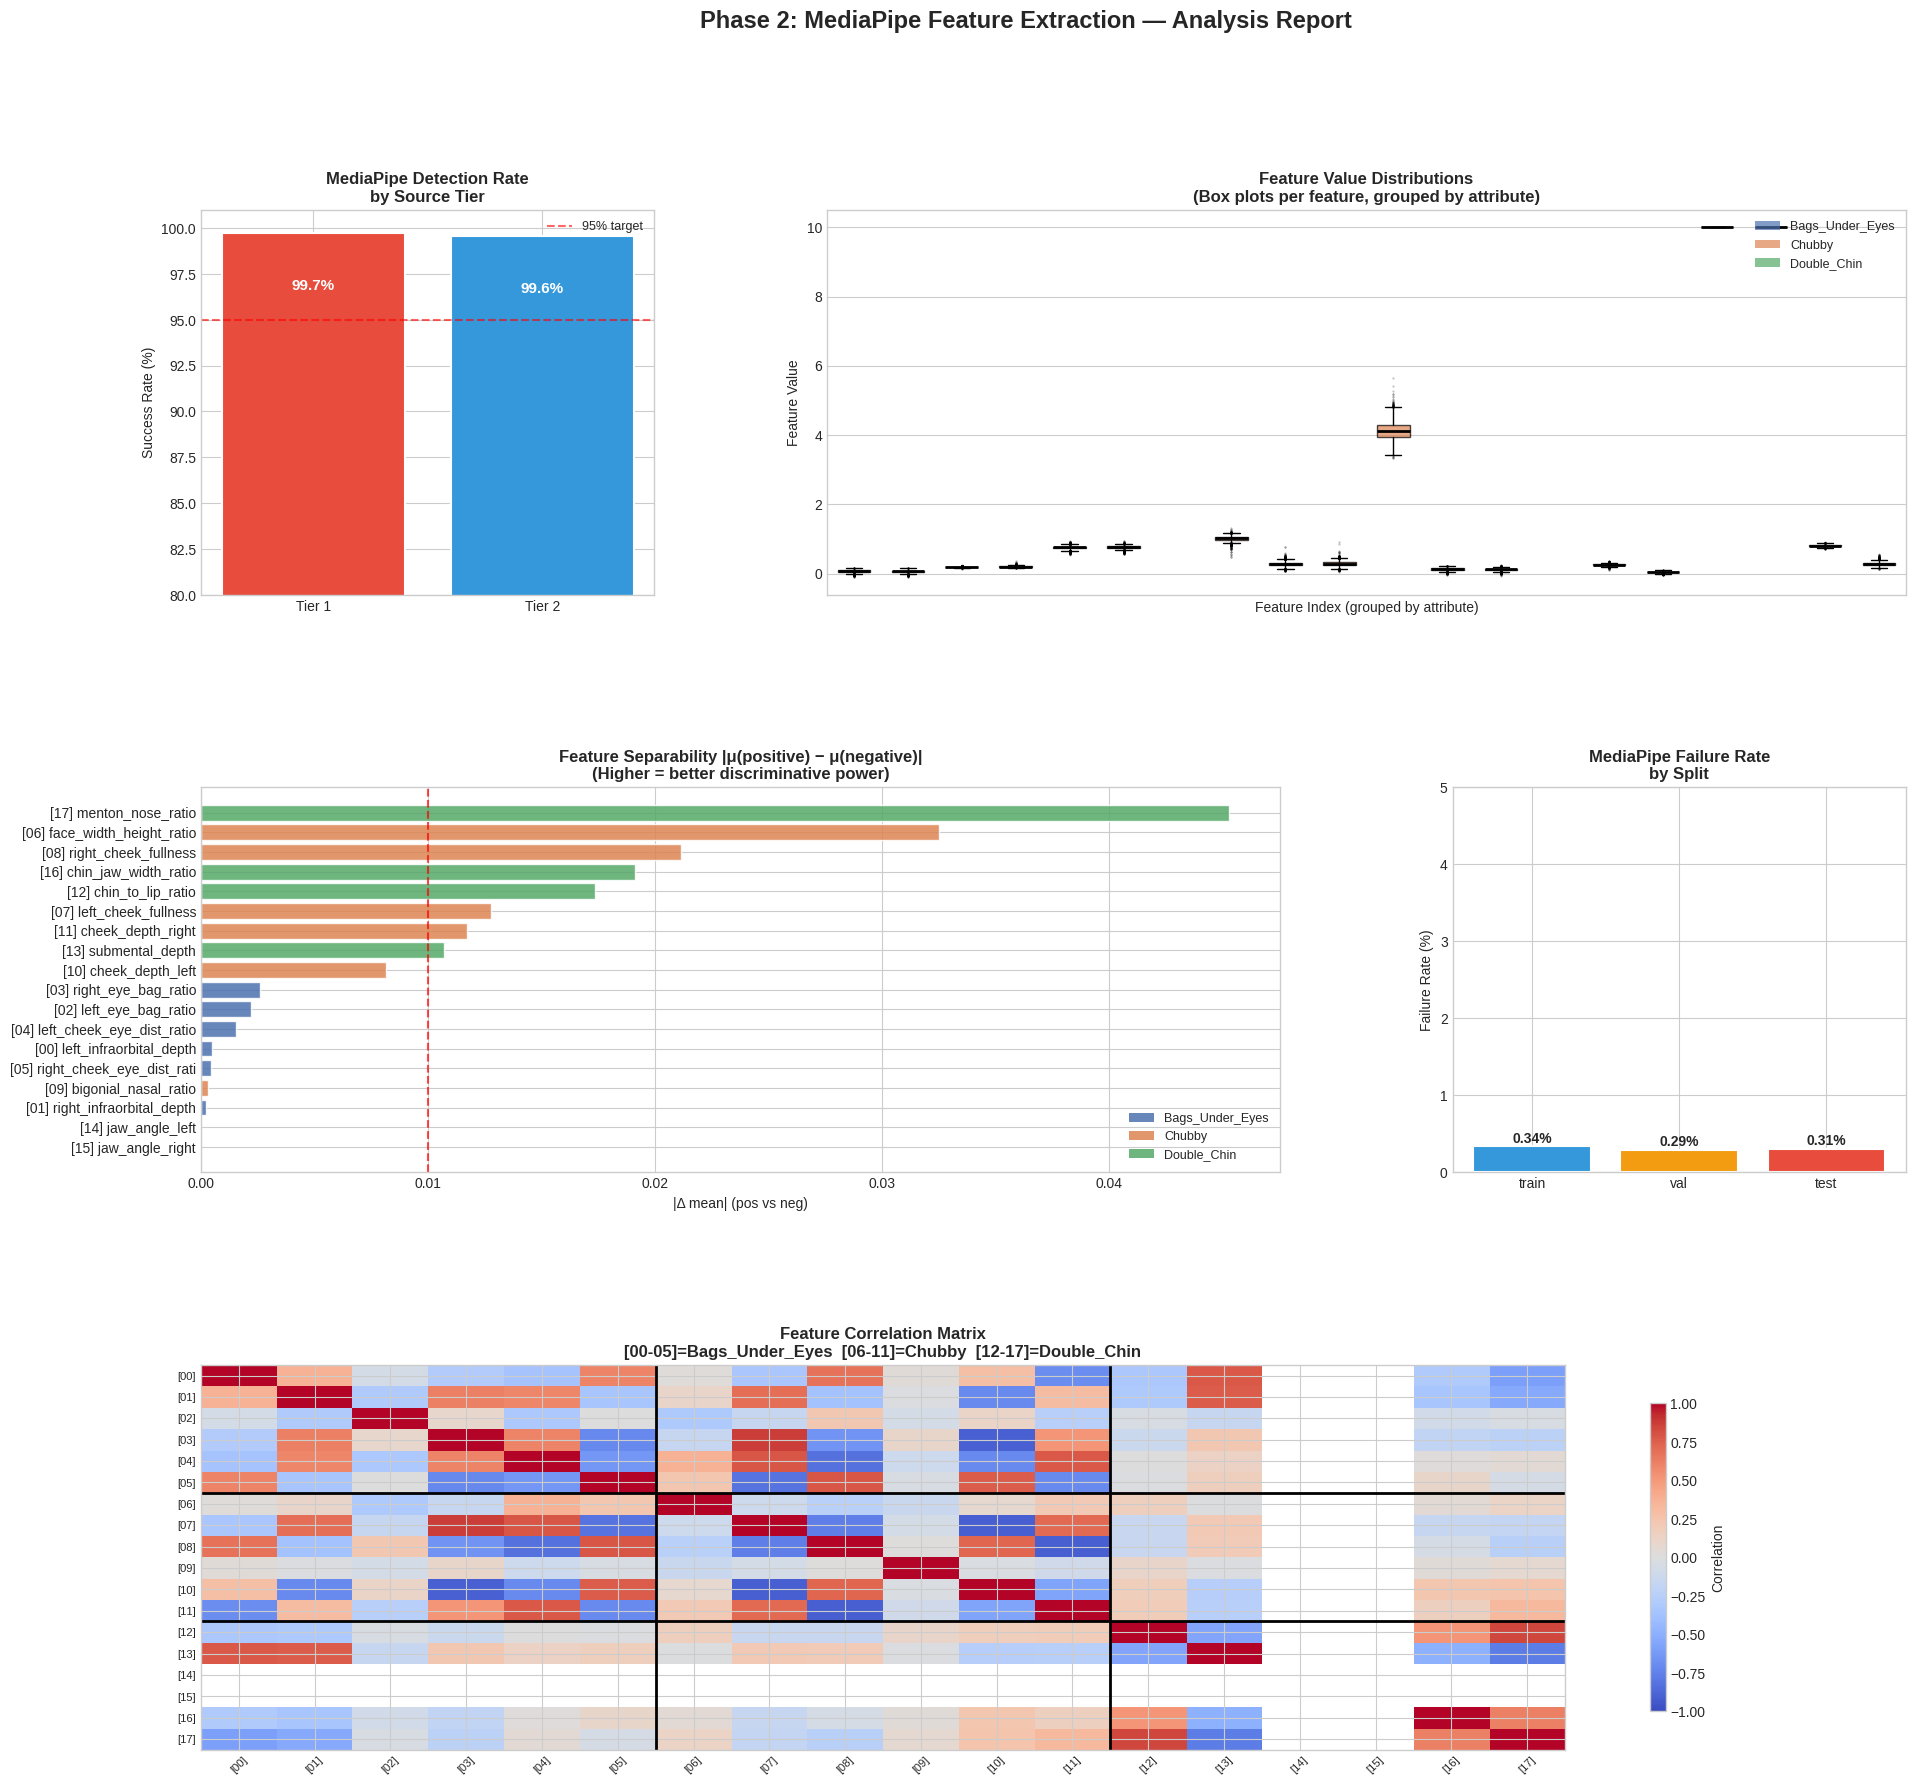

✓ Phase 2 visualization saved → phase2_analysis.png


In [23]:
# ============================================================
# CELL 22: PHASE 2 VISUALIZATIONS (4-panel)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

fig = plt.figure(figsize=(22, 20))
fig.suptitle(
    "Phase 2: MediaPipe Feature Extraction — Analysis Report",
    fontsize=17, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig,
                        hspace=0.50, wspace=0.38)

TARGET_ATTRS = ["Bags_Under_Eyes", "Chubby", "Double_Chin"]
ATTR_COLORS  = {"Bags_Under_Eyes": "#4C72B0",
                "Chubby"         : "#DD8452",
                "Double_Chin"    : "#55A868"}

# ── PLOT 1: MediaPipe success rate per tier ───────────────────
ax1 = fig.add_subplot(gs[0, 0])
success_by_tier = manifest_mp.groupby("source_tier")[
    "mediapipe_success"
].agg(["sum","count"])
success_by_tier["rate"] = (
    success_by_tier["sum"] / success_by_tier["count"] * 100
)
tiers = success_by_tier.index.tolist()
rates = success_by_tier["rate"].tolist()
colors_t = ["#E74C3C","#3498DB","#2ECC71"][:len(tiers)]
bars1 = ax1.bar(
    [f"Tier {t}" for t in tiers], rates,
    color=colors_t, edgecolor="white", linewidth=1.5
)
for bar, rate in zip(bars1, rates):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() - 2.5,
        f"{rate:.1f}%", ha="center", va="top",
        fontsize=11, fontweight="bold", color="white"
    )
ax1.set_ylim(80, 101)
ax1.set_ylabel("Success Rate (%)")
ax1.set_title("MediaPipe Detection Rate\nby Source Tier",
              fontweight="bold")
ax1.axhline(95, color="red", linestyle="--",
            alpha=0.6, label="95% target")
ax1.legend(fontsize=9)

# ── PLOT 2: Feature value distributions (violin) ─────────────
ax2 = fig.add_subplot(gs[0, 1:])
feat_data = []
for i, name in enumerate(FEATURE_NAMES):
    attr = FEATURE_DEFINITIONS[i]["attr"]
    for val in feature_matrix[:, i]:
        feat_data.append({
            "Feature"  : f"[{i:02d}]\n{name.split('_')[0]}",
            "Value"    : float(val),
            "Attribute": attr,
        })
df_violin = pd.DataFrame(feat_data)

# Group by attribute for coloring
for j, attr in enumerate(TARGET_ATTRS):
    feat_indices = [
        i for i, fd in enumerate(FEATURE_DEFINITIONS)
        if fd["attr"] == attr
    ]
    feat_names_attr = [
        f"[{i:02d}]\n{FEATURE_NAMES[i][:10]}"
        for i in feat_indices
    ]
    subset = df_violin[
        df_violin["Attribute"] == attr
    ]
    # Box plot per feature within attribute
    for k, fidx in enumerate(feat_indices):
        col_data = feature_matrix[:, fidx]
        bp = ax2.boxplot(
            col_data,
            positions=[j * 7 + k],
            widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor=ATTR_COLORS[attr],
                          alpha=0.7),
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(linewidth=1),
            flierprops=dict(marker=".", markersize=1,
                            alpha=0.3),
        )

ax2.set_title("Feature Value Distributions\n"
              "(Box plots per feature, grouped by attribute)",
              fontweight="bold")
ax2.set_xlabel("Feature Index (grouped by attribute)")
ax2.set_ylabel("Feature Value")
ax2.set_xticks([])

# Legend
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor=ATTR_COLORS[a], alpha=0.7, label=a)
    for a in TARGET_ATTRS
]
ax2.legend(handles=legend_elems, loc="upper right", fontsize=9)

# ── PLOT 3: Feature separability bar chart ────────────────────
ax3 = fig.add_subplot(gs[1, :2])
labels_sample_arr = df_sample[TARGET_ATTRS].values

sep_data = []
for i, (name, fdef) in enumerate(
        zip(FEATURE_NAMES, FEATURE_DEFINITIONS)):
    attr     = fdef["attr"]
    attr_idx = TARGET_ATTRS.index(attr)
    lbl_col  = labels_sample_arr[:, attr_idx]
    pos_mask = lbl_col ==  1
    neg_mask = lbl_col == -1
    if pos_mask.sum() < 5:
        continue
    mu_pos = feature_matrix[pos_mask, i].mean()
    mu_neg = feature_matrix[neg_mask, i].mean()
    sep_data.append({
        "name"  : f"[{i:02d}] {name[:25]}",
        "delta" : abs(mu_pos - mu_neg),
        "attr"  : attr,
        "mu_pos": mu_pos,
        "mu_neg": mu_neg,
    })

df_sep = pd.DataFrame(sep_data).sort_values("delta",
                                             ascending=True)
colors_sep = [ATTR_COLORS[a] for a in df_sep["attr"]]
bars3 = ax3.barh(df_sep["name"], df_sep["delta"],
                  color=colors_sep, edgecolor="white",
                  linewidth=1, alpha=0.85)
ax3.set_title("Feature Separability |μ(positive) − μ(negative)|\n"
              "(Higher = better discriminative power)",
              fontweight="bold")
ax3.set_xlabel("|Δ mean| (pos vs neg)")
ax3.axvline(0.01, color="red", linestyle="--",
            alpha=0.7, label="|Δ|=0.01 threshold")
ax3.legend(fontsize=9)
legend_elems2 = [
    Patch(facecolor=ATTR_COLORS[a], alpha=0.85, label=a)
    for a in TARGET_ATTRS
]
ax3.legend(handles=legend_elems2, loc="lower right", fontsize=9)

# ── PLOT 4: Extraction failure analysis ───────────────────────
ax4 = fig.add_subplot(gs[1, 2])
fail_by_split = manifest_mp.groupby("split").agg(
    total     = ("mediapipe_success", "count"),
    succeeded = ("mediapipe_success", "sum"),
).reset_index()
fail_by_split["failed"] = (
    fail_by_split["total"] - fail_by_split["succeeded"]
)
fail_by_split["fail_rate"] = (
    fail_by_split["failed"] / fail_by_split["total"] * 100
)

split_order = ["train","val","test"]
fail_by_split = fail_by_split.set_index("split").reindex(
    split_order
).reset_index()

ax4.bar(fail_by_split["split"],
        fail_by_split["fail_rate"],
        color=["#3498DB","#F39C12","#E74C3C"],
        edgecolor="white", linewidth=1.5)
for i, row in fail_by_split.iterrows():
    ax4.text(i, row["fail_rate"] + 0.05,
             f"{row['fail_rate']:.2f}%",
             ha="center", fontsize=10, fontweight="bold")
ax4.set_title("MediaPipe Failure Rate\nby Split",
              fontweight="bold")
ax4.set_ylabel("Failure Rate (%)")
ax4.set_ylim(0, max(fail_by_split["fail_rate"].max() + 1, 5))

# ── PLOT 5: Feature correlation heatmap ──────────────────────
ax5 = fig.add_subplot(gs[2, :])
corr_mat = np.corrcoef(feature_matrix.T)
short_names = [f"[{i:02d}]" for i in range(N_FEATURES)]
mask = np.zeros_like(corr_mat, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

# Annotate with attribute grouping via color bar
im = ax5.imshow(corr_mat, cmap="coolwarm",
                vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax5, shrink=0.8, label="Correlation")
ax5.set_xticks(range(N_FEATURES))
ax5.set_yticks(range(N_FEATURES))
ax5.set_xticklabels(short_names, rotation=45, fontsize=8)
ax5.set_yticklabels(short_names, fontsize=8)
ax5.set_title(
    "Feature Correlation Matrix\n"
    "[00-05]=Bags_Under_Eyes  "
    "[06-11]=Chubby  "
    "[12-17]=Double_Chin",
    fontweight="bold"
)
# Draw group boundaries
for boundary in [6, 12]:
    ax5.axhline(boundary - 0.5, color="black",
                linewidth=2, linestyle="-")
    ax5.axvline(boundary - 0.5, color="black",
                linewidth=2, linestyle="-")

plt.savefig(
    OUTPUT_DIR / "phase2_analysis.png",
    dpi=150, bbox_inches="tight", facecolor="white"
)
plt.show()
print("✓ Phase 2 visualization saved → phase2_analysis.png")

In [24]:
# ============================================================
# CELL 23: PHASE 2 FINAL SUMMARY & HANDOFF
# ============================================================

import json

manifest_final = pd.read_csv(MANIFEST_MP_PATH)

# ── Update stats JSON ─────────────────────────────────────────
with open(Path("/kaggle/working/dataset_stats.json")) as f:
    stats = json.load(f)

stats["mediapipe"] = {
    "n_features"         : int(N_FEATURES),
    "feature_names"      : FEATURE_NAMES,
    "total_processed"    : int(len(manifest_final)),
    "total_success"      : int(manifest_final["mediapipe_success"].sum()),
    "success_rate_pct"   : round(
        manifest_final["mediapipe_success"].mean() * 100, 2
    ),
    "total_failed"       : int(
        (manifest_final["mediapipe_success"] == 0).sum()
    ),
    "feature_dir"        : str(FEATURE_DIR),
    "manifest_mp_path"   : str(MANIFEST_MP_PATH),
    "npy_files_on_disk"  : len(list(FEATURE_DIR.glob("*.npy"))),
}

with open(Path("/kaggle/working/dataset_stats.json"), "w") as f:
    json.dump(stats, f, indent=2)

# ── Print summary ─────────────────────────────────────────────
print("=" * 65)
print("  PHASE 2 COMPLETE — FINAL SUMMARY")
print("=" * 65)
print(f"""
  MEDIAPIPE EXTRACTION RESULTS
  ─────────────────────────────────────────────────────────
  Total images processed    : {len(manifest_final):>8,}
  Successful detections     : {manifest_final['mediapipe_success'].sum():>8,}  ({manifest_final['mediapipe_success'].mean()*100:.2f}%)
  Failed detections         : {(manifest_final['mediapipe_success']==0).sum():>8,}  ({(manifest_final['mediapipe_success']==0).mean()*100:.2f}%)
  Features per image        : {N_FEATURES}

  FEATURE BREAKDOWN BY ATTRIBUTE
  ─────────────────────────────────────────────────────────
  Bags_Under_Eyes features  : 6  [indices 00-05]
  Chubby features           : 6  [indices 06-11]
  Double_Chin features      : 6  [indices 12-17]

  OUTPUT FILES
  ─────────────────────────────────────────────────────────
  manifest_with_mp.csv      : {str(MANIFEST_MP_PATH)}
  mediapipe_features/       : {len(list(FEATURE_DIR.glob('*.npy'))):,} .npy files
  dataset_stats.json        : updated with mediapipe stats
  logs/mediapipe_extraction.log
  logs/failed_images.csv    : (if any failures)
  phase2_analysis.png       : visualization report

  MODULAR FILES WRITTEN
  ─────────────────────────────────────────────────────────
  src/__init__.py
  src/landmark_config.py    ← 18 feature definitions
  src/feature_utils.py      ← geometric computations
  src/mediapipe_extractor.py← FaceGeometricExtractor class

  NEXT STEP → Phase 3: Dataset & DataLoader Classes
              Input : manifest_with_mp.csv
              Output: CelebADataset class + DataLoaders
""")
print("=" * 65)

  PHASE 2 COMPLETE — FINAL SUMMARY

  MEDIAPIPE EXTRACTION RESULTS
  ─────────────────────────────────────────────────────────
  Total images processed    :  100,000
  Successful detections     :   99,671  (99.67%)
  Failed detections         :      329  (0.33%)
  Features per image        : 18

  FEATURE BREAKDOWN BY ATTRIBUTE
  ─────────────────────────────────────────────────────────
  Bags_Under_Eyes features  : 6  [indices 00-05]
  Chubby features           : 6  [indices 06-11]
  Double_Chin features      : 6  [indices 12-17]

  OUTPUT FILES
  ─────────────────────────────────────────────────────────
  manifest_with_mp.csv      : /kaggle/working/manifest_with_mp.csv
  mediapipe_features/       : 100,000 .npy files
  dataset_stats.json        : updated with mediapipe stats
  logs/mediapipe_extraction.log
  logs/failed_images.csv    : (if any failures)
  phase2_analysis.png       : visualization report

  MODULAR FILES WRITTEN
  ──────────────────────────────────────────────────────

In [25]:
# ============================================================
# CELL 24: CREATE PHASE 3 READY MANIFEST
# ============================================================

import os
import json
import shutil
import zipfile
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

WORKING_DIR = Path("/kaggle/working")
FEATURE_DIR = WORKING_DIR / "mediapipe_features"
SRC_DIR     = WORKING_DIR / "src"
LOG_DIR     = WORKING_DIR / "logs"

MANIFEST_MP_PATH = WORKING_DIR / "manifest_with_mp.csv"
STATS_PATH       = WORKING_DIR / "dataset_stats.json"

EXPORT_DIR = WORKING_DIR / "phase12_export"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("CREATING PHASE 3 READY MANIFEST")
print("=" * 60)

# Load existing manifest
manifest = pd.read_csv(MANIFEST_MP_PATH)
print(f"Loaded manifest_with_mp.csv: {len(manifest):,} rows")

# ------------------------------------------------------------
# Important:
# Current mediapipe_path is absolute:
# /kaggle/working/mediapipe_features/000001.npy
#
# In the new Phase 3 notebook this path will NOT exist.
# So we add relative paths that Phase 3 can rebuild.
# ------------------------------------------------------------

manifest["mediapipe_filename"] = manifest["image_id"].apply(
    lambda x: Path(x).stem + ".npy"
)

manifest["mediapipe_relpath"] = manifest["mediapipe_filename"].apply(
    lambda x: f"mediapipe_features/{x}"
)

# Keep old mediapipe_path for reference, but Phase 3 will use relpath
PHASE3_MANIFEST_PATH = EXPORT_DIR / "phase3_manifest.csv"
manifest.to_csv(PHASE3_MANIFEST_PATH, index=False)

print(f"Saved Phase 3 manifest:")
print(f"  {PHASE3_MANIFEST_PATH}")
print(f"Columns:")
print(manifest.columns.tolist())

# Quick check
assert "mediapipe_relpath" in manifest.columns
assert "mediapipe_filename" in manifest.columns
assert "mediapipe_success" in manifest.columns

print("\nPhase 3 manifest ready ✓")

CREATING PHASE 3 READY MANIFEST
Loaded manifest_with_mp.csv: 100,000 rows
Saved Phase 3 manifest:
  /kaggle/working/phase12_export/phase3_manifest.csv
Columns:
['image_id', 'img_path', 'source_tier', 'Bags_Under_Eyes', 'Chubby', 'Double_Chin', 'gender', 'sample_weight', 'split', 'mediapipe_path', 'mediapipe_success', 'mediapipe_filename', 'mediapipe_relpath']

Phase 3 manifest ready ✓


In [28]:
# ============================================================
# CELL 25 (FIXED): PREPARE SMALL FILES FOR EXPORT
# ============================================================

import shutil
from pathlib import Path
from datetime import datetime

print("=" * 60)
print("PREPARING SMALL FILES FOR EXPORT")
print("=" * 60)

WORKING_DIR = Path("/kaggle/working")
FEATURE_DIR = WORKING_DIR / "mediapipe_features"
SRC_DIR     = WORKING_DIR / "src"
LOG_DIR     = WORKING_DIR / "logs"
EXPORT_DIR  = WORKING_DIR / "phase12_export"

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
(EXPORT_DIR / "src").mkdir(exist_ok=True)
(EXPORT_DIR / "logs").mkdir(exist_ok=True)

def safe_copy(src: Path, dst: Path):
    """
    Copy src to dst safely.
    Skips if src and dst are the same file.
    """
    src = Path(src)
    dst = Path(dst)

    if not src.exists():
        print(f"  ✗ Missing {src}")
        return

    dst.parent.mkdir(parents=True, exist_ok=True)

    try:
        if src.resolve() == dst.resolve():
            print(f"  → Skipped same file: {src.name}")
            return
    except Exception:
        pass

    shutil.copy2(src, dst)
    print(f"  ✓ Copied {src.name}")

# ------------------------------------------------------------
# Required small files
# ------------------------------------------------------------

small_files = [
    (WORKING_DIR / "manifest.csv",
     EXPORT_DIR / "manifest.csv"),

    (WORKING_DIR / "manifest_with_mp.csv",
     EXPORT_DIR / "manifest_with_mp.csv"),

    # phase3_manifest.csv was already created inside EXPORT_DIR
    # by Cell 24, so this copy may be same-file. safe_copy handles it.
    (EXPORT_DIR / "phase3_manifest.csv",
     EXPORT_DIR / "phase3_manifest.csv"),

    (WORKING_DIR / "dataset_stats.json",
     EXPORT_DIR / "dataset_stats.json"),
]

for src, dst in small_files:
    safe_copy(src, dst)

# ------------------------------------------------------------
# Optional files
# ------------------------------------------------------------

optional_files = [
    WORKING_DIR / "phase1_analysis.png",
    WORKING_DIR / "phase2_analysis.png",
    WORKING_DIR / "face_landmarker.task",
]

for src in optional_files:
    if src.exists():
        safe_copy(src, EXPORT_DIR / src.name)
    else:
        print(f"  → Optional missing, skipped: {src.name}")

# ------------------------------------------------------------
# Copy src/ Python modules
# ------------------------------------------------------------

print("\nCopying src/ modules...")

if SRC_DIR.exists():
    for py_file in SRC_DIR.glob("*.py"):
        safe_copy(py_file, EXPORT_DIR / "src" / py_file.name)
else:
    print(f"  ✗ SRC_DIR missing: {SRC_DIR}")

# ------------------------------------------------------------
# Copy logs if present
# ------------------------------------------------------------

print("\nCopying logs...")

if LOG_DIR.exists():
    for log_file in LOG_DIR.glob("*"):
        if log_file.is_file():
            safe_copy(log_file, EXPORT_DIR / "logs" / log_file.name)
else:
    print(f"  → LOG_DIR missing, skipped logs")

# ------------------------------------------------------------
# Create README
# ------------------------------------------------------------

README_TEXT = f"""
CelebA Phase 1 + Phase 2 Prepared Dataset
=========================================

Created at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

Contents:
---------
1. phase3_manifest.csv
   Main manifest for Phase 3.
   Use this instead of manifest_with_mp.csv.

2. manifest_with_mp.csv
   Original Phase 2 manifest with absolute mediapipe_path.

3. dataset_stats.json
   Contains class weights, split counts, MediaPipe stats.

4. src/
   Modular Python files:
   - landmark_config.py
   - feature_utils.py
   - mediapipe_extractor.py
   - __init__.py

5. mediapipe_features/
   Stored separately inside feature ZIP chunks.
   Each .npy file has shape (18,), dtype float32.

Important Phase 3 Note:
-----------------------
Do NOT use old absolute mediapipe_path directly.
Use mediapipe_relpath from phase3_manifest.csv and rebuild full path
inside the new notebook.

Required original image dataset:
--------------------------------
Add this Kaggle dataset in Phase 3:
jessicali9530/celeba-dataset

Targets:
--------
- Bags_Under_Eyes
- Chubby
- Double_Chin

MediaPipe:
----------
Total features per image: 18
Successful detections: 99,671 / 100,000
Failed detections: 329 / 100,000
"""

README_PATH = EXPORT_DIR / "README_PHASE12.txt"

with open(README_PATH, "w") as f:
    f.write(README_TEXT)

print(f"\n✓ README created: {README_PATH}")

# ------------------------------------------------------------
# Final listing
# ------------------------------------------------------------

print("\nExport folder contents:")
print("-" * 60)

for p in sorted(EXPORT_DIR.rglob("*")):
    if p.is_file():
        size_kb = p.stat().st_size / 1024
        print(f"  {str(p.relative_to(EXPORT_DIR)):<45s} {size_kb:>8.1f} KB")

print("\nCell 25 complete ✓")
print("Now continue to Cell 26.")

PREPARING SMALL FILES FOR EXPORT
  ✓ Copied manifest.csv
  ✓ Copied manifest_with_mp.csv
  → Skipped same file: phase3_manifest.csv
  ✓ Copied dataset_stats.json
  ✓ Copied phase1_analysis.png
  ✓ Copied phase2_analysis.png
  ✓ Copied face_landmarker.task

Copying src/ modules...
  ✓ Copied mediapipe_extractor.py
  ✓ Copied __init__.py
  ✓ Copied landmark_config.py
  ✓ Copied feature_utils.py

Copying logs...
  ✓ Copied failed_images.csv
  ✓ Copied mediapipe_extraction.log

✓ README created: /kaggle/working/phase12_export/README_PHASE12.txt

Export folder contents:
------------------------------------------------------------
  README_PHASE12.txt                                 1.1 KB
  dataset_stats.json                                 1.4 KB
  face_landmarker.task                            3670.5 KB
  logs/failed_images.csv                            30.1 KB
  logs/mediapipe_extraction.log                     18.3 KB
  manifest.csv                                   13568.7 KB
  manif

In [29]:
# ============================================================
# CELL 26: CREATE MANIFEST + CODE ZIP
# ============================================================

ZIP_SMALL = WORKING_DIR / "celeba_phase12_manifest_code.zip"

print("=" * 60)
print("CREATING SMALL ZIP: manifest + code + stats")
print("=" * 60)

# Remove old zip if exists
if ZIP_SMALL.exists():
    ZIP_SMALL.unlink()

with zipfile.ZipFile(
    ZIP_SMALL,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6
) as zf:
    for file_path in EXPORT_DIR.rglob("*"):
        if file_path.is_file():
            arcname = file_path.relative_to(EXPORT_DIR)
            zf.write(file_path, arcname)
            print(f"  ✓ Added {arcname}")

zip_size = ZIP_SMALL.stat().st_size / 1024 / 1024

print("\nSmall ZIP created:")
print(f"  Path: {ZIP_SMALL}")
print(f"  Size: {zip_size:.2f} MB")

CREATING SMALL ZIP: manifest + code + stats
  ✓ Added face_landmarker.task
  ✓ Added manifest.csv
  ✓ Added dataset_stats.json
  ✓ Added phase2_analysis.png
  ✓ Added phase1_analysis.png
  ✓ Added phase3_manifest.csv
  ✓ Added manifest_with_mp.csv
  ✓ Added README_PHASE12.txt
  ✓ Added src/mediapipe_extractor.py
  ✓ Added src/__init__.py
  ✓ Added src/landmark_config.py
  ✓ Added src/feature_utils.py
  ✓ Added logs/failed_images.csv
  ✓ Added logs/mediapipe_extraction.log

Small ZIP created:
  Path: /kaggle/working/celeba_phase12_manifest_code.zip
  Size: 7.16 MB


In [30]:
# ============================================================
# CELL 27: CREATE MEDIAPIPE FEATURE ZIP CHUNKS
# ============================================================

print("=" * 60)
print("CREATING MEDIAPIPE FEATURE ZIP CHUNKS")
print("=" * 60)

npy_files = sorted(FEATURE_DIR.glob("*.npy"))

print(f"Total .npy files found: {len(npy_files):,}")

assert len(npy_files) == 100_000, (
    f"Expected 100,000 .npy files, found {len(npy_files):,}"
)

CHUNK_SIZE = 25_000
N_CHUNKS = (len(npy_files) + CHUNK_SIZE - 1) // CHUNK_SIZE

feature_zip_paths = []

for chunk_idx in range(N_CHUNKS):
    start = chunk_idx * CHUNK_SIZE
    end   = min(start + CHUNK_SIZE, len(npy_files))

    chunk_files = npy_files[start:end]

    zip_path = WORKING_DIR / (
        f"celeba_phase12_features_part"
        f"{chunk_idx+1:02d}_of_{N_CHUNKS:02d}.zip"
    )

    # Remove old zip if exists
    if zip_path.exists():
        zip_path.unlink()

    print(f"\nCreating {zip_path.name}")
    print(f"  Files {start:,} to {end:,}")

    with zipfile.ZipFile(
        zip_path,
        "w",
        compression=zipfile.ZIP_DEFLATED,
        compresslevel=1
    ) as zf:
        for file_path in chunk_files:
            arcname = f"mediapipe_features/{file_path.name}"
            zf.write(file_path, arcname)

    size_mb = zip_path.stat().st_size / 1024 / 1024
    feature_zip_paths.append(zip_path)

    print(f"  ✓ Done: {size_mb:.2f} MB")

print("\nAll feature chunks created ✓")
print(f"Number of chunks: {len(feature_zip_paths)}")

CREATING MEDIAPIPE FEATURE ZIP CHUNKS
Total .npy files found: 100,000

Creating celeba_phase12_features_part01_of_04.zip
  Files 0 to 25,000
  ✓ Done: 6.55 MB

Creating celeba_phase12_features_part02_of_04.zip
  Files 25,000 to 50,000
  ✓ Done: 6.55 MB

Creating celeba_phase12_features_part03_of_04.zip
  Files 50,000 to 75,000
  ✓ Done: 6.55 MB

Creating celeba_phase12_features_part04_of_04.zip
  Files 75,000 to 100,000
  ✓ Done: 6.55 MB

All feature chunks created ✓
Number of chunks: 4


In [32]:
# ============================================================
# CELL 29 (FIXED): FINAL FILE LIST FOR KAGGLE DATASET UPLOAD
# Rebuilds variables from disk, no dependency on previous vars
# ============================================================

import json
from pathlib import Path
from datetime import datetime

WORKING_DIR = Path("/kaggle/working")

print("=" * 60)
print("FINAL FILES TO UPLOAD")
print("=" * 60)

# ------------------------------------------------------------
# Rebuild ZIP paths from disk
# ------------------------------------------------------------

ZIP_SMALL = WORKING_DIR / "celeba_phase12_manifest_code.zip"

feature_zip_paths = sorted(
    WORKING_DIR.glob("celeba_phase12_features_part*_of_*.zip")
)

SUMMARY_PATH = WORKING_DIR / "phase12_upload_summary.json"

# ------------------------------------------------------------
# Validate required files
# ------------------------------------------------------------

missing = []

if not ZIP_SMALL.exists():
    missing.append(ZIP_SMALL.name)

if len(feature_zip_paths) == 0:
    missing.append("celeba_phase12_features_partXX_ofXX.zip files")

if missing:
    print("\nERROR: Missing required upload files:")
    for m in missing:
        print(f"  ✗ {m}")
    print("\nRun Cell 26 and Cell 27 again before this cell.")
    raise FileNotFoundError("Required ZIP files missing")

# ------------------------------------------------------------
# Create summary JSON if it does not exist
# ------------------------------------------------------------

if not SUMMARY_PATH.exists():
    print("\nphase12_upload_summary.json not found.")
    print("Creating it now...")

    summary = {
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "small_zip": ZIP_SMALL.name,
        "feature_zips": [p.name for p in feature_zip_paths],
        "note": (
            "Created automatically by fixed Cell 29. "
            "Contains Phase 1 + Phase 2 prepared outputs."
        )
    }

    with open(SUMMARY_PATH, "w") as f:
        json.dump(summary, f, indent=2)

    print(f"  ✓ Created {SUMMARY_PATH.name}")
else:
    print(f"\nFound summary file: {SUMMARY_PATH.name}")

# ------------------------------------------------------------
# Final upload file list
# ------------------------------------------------------------

upload_files = [ZIP_SMALL] + feature_zip_paths + [SUMMARY_PATH]

total_size = 0.0

print("\nFiles to upload:")
print("-" * 75)
print(f"{'Filename':<60s} {'Size':>10s}")
print("-" * 75)

for fp in upload_files:
    size_mb = fp.stat().st_size / 1024 / 1024
    total_size += size_mb
    print(f"{fp.name:<60s} {size_mb:>8.2f} MB")

print("-" * 75)
print(f"{'TOTAL':<60s} {total_size:>8.2f} MB")

# ------------------------------------------------------------
# Final instructions
# ------------------------------------------------------------

print("""
NEXT MANUAL STEP:
=================

Create ONE Kaggle Dataset containing all files listed above.

Recommended dataset name:
  celeba-phase12-prepared

Upload these files:
  1. celeba_phase12_manifest_code.zip
  2. celeba_phase12_features_part01_of04.zip
  3. celeba_phase12_features_part02_of04.zip
  4. celeba_phase12_features_part03_of04.zip
  5. celeba_phase12_features_part04_of04.zip
  6. phase12_upload_summary.json

In the new Phase 3 notebook, add these datasets:
  1. jessicali9530/celeba-dataset
  2. celeba-phase12-prepared

Phase 3 will unzip the prepared dataset and load:
  phase3_manifest.csv
  mediapipe_features/*.npy
  src/
""")

print("Cell 29 complete ✓")

FINAL FILES TO UPLOAD

phase12_upload_summary.json not found.
Creating it now...
  ✓ Created phase12_upload_summary.json

Files to upload:
---------------------------------------------------------------------------
Filename                                                           Size
---------------------------------------------------------------------------
celeba_phase12_manifest_code.zip                                 7.16 MB
celeba_phase12_features_part01_of_04.zip                         6.55 MB
celeba_phase12_features_part02_of_04.zip                         6.55 MB
celeba_phase12_features_part03_of_04.zip                         6.55 MB
celeba_phase12_features_part04_of_04.zip                         6.55 MB
phase12_upload_summary.json                                      0.00 MB
---------------------------------------------------------------------------
TOTAL                                                           33.36 MB

NEXT MANUAL STEP:

Create ONE Kaggle Dataset cont